# EBSD Tensorial WTMM — Per-Grain Demean

Pipeline:
1. Load EBSD map, assign per-phase symmetry groups.
2. **Symmetry-aware adjacency flood-fill** → grain labels (no kernels).
3. **Per-grain Karcher-mean reference** $q_{\mathrm{ref},g}$.
4. **Per-grain demean** → log orientation field $\mathbf{v}(\mathbf{x}) = \log(q_{\mathrm{ref},g(\mathbf{x})}^{-1}\,q(\mathbf{x})) \in \mathfrak{so}(3)$, FZ-reduced.
5. Optional: c-axis-to-Z rotation per grain (quartz).
6. Optional: GB mask with per-scale dilation for **chain-level** filtering (fallback mode).
7. CWT + tensor SVD + WTMM chains + partition function.

See `tensorial_wtmm_math.tex` for the math.

**Why per-grain demean?** Two sides of a grain boundary both sit near the identity after per-grain demean, so $\mathbf{v}$ is continuous across GBs by construction — no artificial step singularities in the log field. This makes the WTMM measure intragranular multifractality rather than the GB network. Chain-level GB filter is kept as a fallback for per-phase or global-reference runs.


In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')
EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')


MLX: 0.31.1, xsmurf: 0.1.0
orix available for rotation + symmetry ops


In [110]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined


In [111]:
%matplotlib widget


In [112]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


In [113]:
EBSD_DIR = Path('EBSD')

# --- Loadable files: .ctf (ASCII) and .cpr (Oxford binary via read_cpr) ---
ctf_files = sorted(EBSD_DIR.rglob('*.ctf'))
cpr_files = sorted(EBSD_DIR.rglob('*.cpr'))
ebsd_files = sorted(ctf_files + cpr_files, key=lambda p: (p.parts[:-1], p.name))

# Shear-zone folder tags
SHEAR_ZONE_TAGS = {
    'Calamita_Elba_Quartzite':           ('[CAL]', 'Calamita quartzite'),
    'Kuckaus_Namibia_Feldspar_Mylonite': ('[KUC]', 'Kuckaus polymineralic mylonite'),
    'Josephine_Peridotite_Olivine':      ('[JOS]', 'Josephine peridotite'),
}

def _tag(path):
    rel = path.relative_to(EBSD_DIR)
    root = rel.parts[0] if rel.parts else ''
    return SHEAR_ZONE_TAGS.get(root, ('[...]', root))[0]

labels = []
for p in ebsd_files:
    rel = p.relative_to(EBSD_DIR)
    labels.append(f'{_tag(p)} {rel}  [{p.suffix[1:]}]')

print(f'Found {len(ebsd_files)} EBSD files ({len(ctf_files)} CTF + {len(cpr_files)} CPR):\n')
from collections import defaultdict
by_tag = defaultdict(list)
for i, p in enumerate(ebsd_files):
    by_tag[_tag(p)].append(i)
for tag, idxs in by_tag.items():
    print(f'  {tag}  ({len(idxs)} files)')
    for i in idxs:
        rel = ebsd_files[i].relative_to(EBSD_DIR)
        print(f'    [{i:3d}] {rel}  [{ebsd_files[i].suffix[1:]}]')
    print()


Found 61 EBSD files (54 CTF + 7 CPR):

  [...]  (24 files)
    [  0] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf  [ctf]
    [  1] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf  [ctf]
    [  2] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf  [ctf]
    [  3] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf  [ctf]
    [  4] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf  [ctf]
    [  5] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf  [ctf]
    [  6] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf  [ctf]
    [  7] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf  [ctf]
    [  8] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf  [ctf]
    [  9] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf  [ctf]
    [ 10] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf  [ctf]
    [ 11] 2015-06-26_Pearce_Mark_13963v1/data/Twinn

In [114]:
# ---- Pick a dataset by index ----
DATASET_IDX = 60# <-- change this to select a different file

ebsd_path = ebsd_files[DATASET_IDX]
ctf_path = ebsd_path                        # alias: downstream cells look at ctf_path
print(f'Selected: {labels[DATASET_IDX]}')
print(f'  Path: {ebsd_path}')

ebsd = read_ebsd(ebsd_path)
meta = ebsd['meta']


Selected: [KUC] Kuckaus_Namibia_Feldspar_Mylonite/Ultramylonite .cpr  [cpr]
  Path: EBSD/Kuckaus_Namibia_Feldspar_Mylonite/Ultramylonite .cpr
  CPR: 700x701 @ 0.2 um, 5 phases, 20 fields


Phases: {np.uint8(0): np.int64(140720), np.uint8(1): np.int64(114753), np.uint8(2): np.int64(149598), np.uint8(3): np.int64(76232), np.uint8(4): np.int64(4365), np.uint8(5): np.int64(5032)}
Dominant phase: 2
  Phase 2: Orthoclase, Laue=2 -> Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]]
Phase mask: 149598/490700 (30.5%)
Computing KAM (kernel=1)...
  Kernel=1 -> 3x3, 4 unique neighbor pairs


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_2713/1500603122.py:91: RuntimeWarning: invalid value encountered in divide
  kam = np.where(count > 0, kam / count, 0)


KAM: [0.0000, 179.7932] deg, median=0.3923


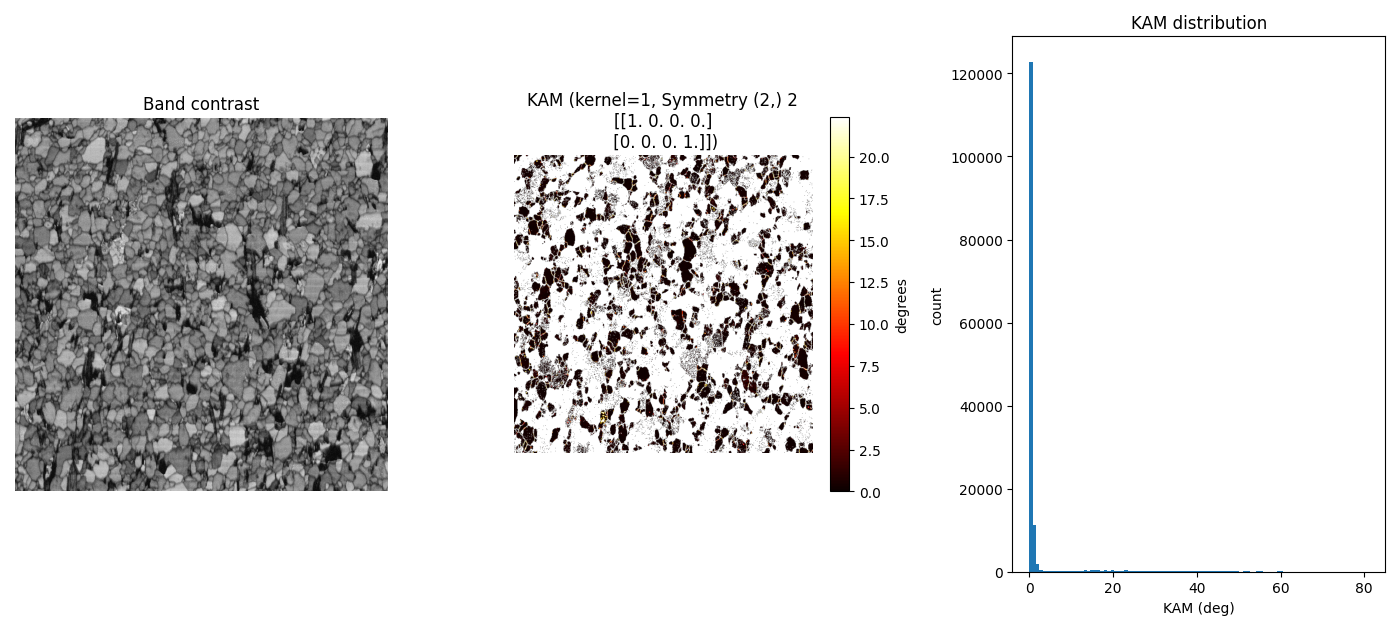

In [115]:
# ===== KAM via orix (symmetry-aware) =====

from orix.quaternion import Orientation
from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh

# ---------- USER PARAMETERS ----------
KAM_KERNEL = 1   # Kernel radius: 1 = 3x3, 2 = 5x5, 3 = 7x7, etc.
# --------------------------------------

LAUE_TO_ORIX = {
    '1': C1, '2': C2, '3': D2, '6': D3, '7': D6, '9': Oh, '11': C1,
}

def get_phase_symmetry(ebsd_data, phase_id=1):
    phases = ebsd_data['meta'].get('phases', {})
    if phase_id in phases:
        info = phases[phase_id]
        laue_str = str(info[3]).strip() if len(info) > 3 else '?'
        sym = LAUE_TO_ORIX.get(laue_str, None)
        name = info[2] if len(info) > 2 else f'phase_{phase_id}'
        print(f'  Phase {phase_id}: {name}, Laue={laue_str} -> {sym}')
        return sym
    return None


def compute_kam_orix(e1_deg, e2_deg, e3_deg, symmetry, mask=None,
                      kernel=1, degrees=True):
    """Compute KAM using orix Orientation.angle_with().

    kernel: neighborhood radius in pixels.
        1 = 3x3 (8 neighbors), 2 = 5x5 (24 neighbors), etc.
        Matches MTEX/OIM convention.
    """
    ny, nx = e1_deg.shape
    euler_rad = np.deg2rad(np.stack([e1_deg, e2_deg, e3_deg], axis=-1)).astype(np.float64)

    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=symmetry)
    ori = ori.reshape(ny, nx)

    kam = np.zeros((ny, nx), dtype=np.float64)
    count = np.zeros((ny, nx), dtype=np.float64)

    if mask is None:
        mask = np.ones((ny, nx), dtype=bool)

    # Generate all (dy, dx) offsets within the kernel radius
    offsets = []
    for dy in range(-kernel, kernel + 1):
        for dx in range(-kernel, kernel + 1):
            if dy == 0 and dx == 0:
                continue
            # Only count each pair once: (dy,dx) and (-dy,-dx) are the same pair
            if (dy, dx) > (0, 0) or (dy == 0 and dx > 0):
                offsets.append((dy, dx))

    print(f'  Kernel={kernel} -> {2*kernel+1}x{2*kernel+1}, {len(offsets)} unique neighbor pairs')

    for dy, dx in offsets:
        # Slice pairs so ori1[i,j] is compared with ori2[i,j] = ori1[i+dy, j+dx]
        if dy >= 0:
            sy1 = slice(None, ny - dy) if dy > 0 else slice(None)
            sy2 = slice(dy, None) if dy > 0 else slice(None)
        else:
            sy1 = slice(-dy, None)
            sy2 = slice(None, ny + dy)

        if dx >= 0:
            sx1 = slice(None, nx - dx) if dx > 0 else slice(None)
            sx2 = slice(dx, None) if dx > 0 else slice(None)
        else:
            sx1 = slice(-dx, None)
            sx2 = slice(None, nx + dx)

        o1 = ori[sy1, sx1]
        o2 = ori[sy2, sx2]
        m = mask[sy1, sx1] & mask[sy2, sx2]

        if not m.any():
            continue

        angles = np.full(o1.shape, np.nan)
        angles[m] = o1[m].angle_with(o2[m])
        v = np.isfinite(angles)
        a = np.where(v, angles, 0)

        kam[sy1, sx1] += a
        kam[sy2, sx2] += a
        count[sy1, sx1] += v
        count[sy2, sx2] += v

    kam = np.where(count > 0, kam / count, 0)
    kam[~mask] = np.nan
    if degrees:
        kam = np.rad2deg(kam)
    return kam


# --- Compute KAM for current dataset ---
phase_map = ebsd['phase']
unique_phases, phase_counts = np.unique(phase_map, return_counts=True)
dominant_phase = unique_phases[np.argmax(phase_counts)]
print(f'Phases: {dict(zip(unique_phases, phase_counts))}')
print(f'Dominant phase: {dominant_phase}')

sym = get_phase_symmetry(ebsd, phase_id=dominant_phase)
if sym is None:
    for pid in unique_phases:
        sym = get_phase_symmetry(ebsd, phase_id=int(pid))
        if sym is not None:
            dominant_phase = int(pid)
            break
if sym is None:
    print('WARNING: could not determine symmetry, using C1')
    sym = C1

phase_mask = (phase_map == dominant_phase)
print(f'Phase mask: {phase_mask.sum()}/{phase_mask.size} ({phase_mask.mean():.1%})')

print(f'Computing KAM (kernel={KAM_KERNEL})...')
kam = compute_kam_orix(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                        symmetry=sym, mask=phase_mask,
                        kernel=KAM_KERNEL, degrees=True)
print(f'KAM: [{np.nanmin(kam):.4f}, {np.nanmax(kam):.4f}] deg, median={np.nanmedian(kam):.4f}')

ny, nx = kam.shape
aspect = ny / nx
fig_w = 14
fig_h = max(4, fig_w * aspect * 0.45)

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h))
axes[0].imshow(ebsd['bc'], cmap='gray', aspect='equal')
axes[0].set_title('Band contrast')
im = axes[1].imshow(kam, cmap='hot', vmin=0, vmax=np.nanpercentile(kam, 95), aspect='equal')
axes[1].set_title(f'KAM (kernel={KAM_KERNEL}, {sym})')
plt.colorbar(im, ax=axes[1], label='degrees', shrink=0.7)
axes[2].hist(kam[np.isfinite(kam)].ravel(), bins=100,
             range=(0, np.nanpercentile(kam, 99)))
axes[2].set(xlabel='KAM (deg)', ylabel='count', title='KAM distribution')
for ax in axes[:2]: ax.axis('off')
plt.tight_layout()
plt.show()

In [116]:
# ===== Quaternion helpers (shared) =====
def _quat_mul(a, b):
    """Hamilton product.  Broadcasts over leading dims.  Last dim = 4 (w, x, y, z)."""
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([
        
        aw * bw - ax * bx - ay * by - az * bz,
        aw * bx + ax * bw + ay * bz - az * by,
        aw * by - ax * bz + ay * bw + az * bx,
        aw * bz + ax * by - ay * bx + az * bw,
    ], axis=-1)

def _quat_conj(q):
    out = q.copy()
    out[..., 1:] *= -1.0
    return out


## Grain identification (adjacency flood-fill, no kernels)

In [117]:
# ===== Grain identification via symmetry-aware adjacency flood-fill =====
# No kernels / windows: pixel neighbors only.  scipy.ndimage.label on a
# "same grain" adjacency graph built from per-neighbor misorientation.

from scipy.ndimage import label as ndi_label

# ---- parameters ----
GRAIN_THETA_DEG   = 5.0  # high-angle GB threshold (deg); 2 deg for subgrains
GRAIN_MIN_PIXELS  = 25    # drop grains smaller than this (stats only)
# ---------------------

def _sym_miso_angle(q_a, q_b, sym_q):
    """Symmetry-reduced misorientation angle between two quaternion arrays.
    q_a, q_b: (N, 4) unit quaternions.  sym_q: (S, 4) symmetry ops.
    Returns (N,) angles in radians (smallest under the point group)."""
    q_rel = _quat_mul(_quat_conj(q_a), q_b)           # (N, 4)
    q_sym = _quat_mul(q_rel[:, None, :], sym_q[None, :, :])  # (N, S, 4)
    w = np.abs(q_sym[..., 0])                         # (N, S)
    w_max = np.clip(w.max(axis=1), -1.0, 1.0)
    return 2.0 * np.arccos(w_max)

def identify_grains(ebsd_data, theta_c_deg=GRAIN_THETA_DEG):
    """Symmetry-aware grain segmentation.
    Returns: grain_id (ny, nx) int32 (0 = unindexed/background, ≥1 = grain id).
    Algorithm:
      - for each phase, compute pixel-right and pixel-down misorientation (adjacency only)
      - threshold to build 'same grain' edge graph
      - connected-components label within phase
      - concatenate grain ids across phases with unique offsets
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    # Build unit quaternion map (from Euler via orix)
    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q *= np.where(q[..., 0:1] >= 0, 1.0, -1.0)

    theta_c = np.deg2rad(theta_c_deg)
    grain_id = np.zeros((ny, nx), dtype=np.int32)
    gid_offset = 0

    for pid in [int(p) for p in np.unique(phase) if int(p) > 0]:
        pmask = (phase == pid)
        if pmask.sum() < GRAIN_MIN_PIXELS:
            continue
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        # Right-neighbor misorientation: between (y, x) and (y, x+1)
        a = q[:, :-1, :].reshape(-1, 4)
        b = q[:,  1:, :].reshape(-1, 4)
        theta_right = _sym_miso_angle(a, b, sym_q).reshape(ny, nx - 1)

        # Down-neighbor misorientation: between (y, x) and (y+1, x)
        a = q[:-1, :, :].reshape(-1, 4)
        b = q[ 1:, :, :].reshape(-1, 4)
        theta_down = _sym_miso_angle(a, b, sym_q).reshape(ny - 1, nx)

        # Build same-phase adjacency: both pixels must be in this phase
        both_r = pmask[:, :-1] & pmask[:, 1:]
        both_d = pmask[:-1, :] & pmask[1:, :]

        # Same-grain edges
        same_r = both_r & (theta_right < theta_c)
        same_d = both_d & (theta_down  < theta_c)

        # Expand edge flags to a 4-connected adjacency-friendly mask:
        # a pixel is "connected to its right/down neighbor" iff same_r/same_d is True.
        # scipy.ndimage.label can use a custom structure on a binary image, but we
        # want connectivity conditional on edge labels.  Easiest: build a pseudo-pixel
        # structure by union-find over edges.
        # Use a lightweight Union-Find implementation.
        n_pix = ny * nx
        parent = np.arange(n_pix, dtype=np.int64)

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        def union(i, j):
            ri, rj = find(i), find(j)
            if ri != rj:
                parent[rj] = ri

        ys, xs = np.where(same_r)
        for y, x in zip(ys, xs):
            union(y * nx + x, y * nx + (x + 1))

        ys, xs = np.where(same_d)
        for y, x in zip(ys, xs):
            union(y * nx + x, (y + 1) * nx + x)

        # Harvest roots → local labels
        roots = np.array([find(i) for i in range(n_pix)], dtype=np.int64)
        # Only keep labels inside phase mask
        ravel_mask = pmask.ravel()
        # Remap roots to 1..K
        uniq_roots, inv = np.unique(roots[ravel_mask], return_inverse=True)
        local_lbl = np.zeros(n_pix, dtype=np.int32)
        local_lbl[ravel_mask] = inv.astype(np.int32) + 1
        local_lbl = local_lbl.reshape(ny, nx)

        # Offset and assign
        n_this = int(local_lbl.max())
        lbl_off = np.where(local_lbl > 0, local_lbl + gid_offset, 0)
        grain_id[pmask] = lbl_off[pmask]
        gid_offset += n_this

    return grain_id


# ---- Run ----
grain_id = identify_grains(ebsd, theta_c_deg=GRAIN_THETA_DEG)
n_grains_total = int(grain_id.max())
sizes = np.bincount(grain_id.ravel())[1:]  # skip background
n_big = int((sizes >= GRAIN_MIN_PIXELS).sum())
print(f'Grains found: {n_grains_total} total, {n_big} with >= {GRAIN_MIN_PIXELS} px')
print(f'Median grain size: {int(np.median(sizes)) if len(sizes) else 0} px, '
      f'max: {int(sizes.max()) if len(sizes) else 0} px')


  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 2: Orthoclase, Laue=2 -> Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]]
  Phase 3: Anorthite, Laue=1 -> Symmetry (1,) 1
[[1. 0. 0. 0.]]
  Phase 4: Biotite, Laue=2 -> Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]]
  Phase 5: Muscovite, Laue=2 -> Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]]
Grains found: 47352 total, 1591 with >= 25 px
Median grain size: 1 px, max: 1754 px


## Per-grain demean + log orientation

In [118]:
# ===== Per-grain Karcher mean + demean + log orientation =====
# Per-grain symmetry-aware mean reference; log map reduces to FZ.

# ---- options ----
CAXIS_TO_Z = True     # rotate each grain reference so c-axis || sample Z (quartz only)
FZ_WARN_FRAC = 0.7    # warn when per-pixel disorientation exceeds this fraction of FZ max
# -----------------

# FZ max disorientation (deg) per point group (approximate, proper rotation group)
FZ_MAX_DEG_BY_NAME = {
    'D6h': 93.8, 'D6': 93.8, 'C6h': 93.8, 'C6': 93.8,
    'D4h': 98.4, 'D4': 98.4, 'C4h': 98.4, 'C4': 98.4,
    'D3d': 104.5, 'D3': 104.5, 'C3v': 104.5, 'C3': 120.0,
    'D2h': 120.7, 'D2': 120.7, 'C2h': 180.0, 'C2': 180.0,
    'Ci':  180.0, 'C1':  180.0,
    'Oh':  62.8, 'O':  62.8, 'Td': 62.8, 'Th': 62.8, 'T': 62.8,
    'S6':  180.0, 'S4': 180.0, 'Cs':  180.0,
}

def _karcher_mean_grain(q_grain, sym_q, max_iter=5, tol=1e-4):
    """Symmetry-aware Karcher mean of unit quaternions within a grain."""
    n = len(q_grain)
    q_grain = q_grain * np.where(q_grain[:, 0:1] >= 0, 1.0, -1.0)
    # Seed = orientation tensor dominant eigenvector
    T = (q_grain.T @ q_grain) / n
    _, eigvecs = np.linalg.eigh(T)
    q_ref = eigvecs[:, -1]
    if q_ref[0] < 0:
        q_ref = -q_ref
    for _ in range(max_iter):
        # Choose symmetry-equivalent closest to q_ref for each pixel
        q_sym = _quat_mul(q_grain[:, None, :], sym_q[None, :, :])  # (N, S, 4)
        rel = _quat_mul(_quat_conj(q_ref)[None, None, :], q_sym)
        rel *= np.where(rel[..., 0:1] >= 0, 1.0, -1.0)
        best = np.argmax(rel[..., 0], axis=1)
        q_aligned = q_sym[np.arange(n), best]
        q_aligned *= np.where(q_aligned[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_aligned.T @ q_aligned) / n
        _, eigvecs = np.linalg.eigh(T)
        q_new = eigvecs[:, -1]
        if q_new[0] < 0:
            q_new = -q_new
        if abs(float(q_ref @ q_new)) > 1.0 - tol:
            break
        q_ref = q_new
    return q_ref, q_aligned

def _rotation_to_align_caxis_with_z(q_ref):
    """Return quaternion r such that (r * q_ref) places crystal c-axis along sample Z.
    Crystal c-axis in crystal frame = (0, 0, 1).  Rotate crystal frame by q_ref
    into sample frame; we then want r so that r composed with the rotated c-axis
    points along sample Z.  Implementation: compute rotated c-axis, then rigid
    rotation bringing that vector to (0, 0, 1)."""
    # Rotate (0, 0, 1) by q_ref: v = q_ref * (0,0,0,1) * q_ref^-1
    w, x, y, z = q_ref
    # Quaternion rotation of unit z-axis:
    vx = 2.0 * (x * z + w * y)
    vy = 2.0 * (y * z - w * x)
    vz = 1.0 - 2.0 * (x * x + y * y)
    v = np.array([vx, vy, vz])
    v /= np.linalg.norm(v) + 1e-12
    z_axis = np.array([0.0, 0.0, 1.0])
    cosang = float(np.clip(v @ z_axis, -1.0, 1.0))
    if cosang > 1.0 - 1e-9:
        return np.array([1.0, 0.0, 0.0, 0.0])
    if cosang < -1.0 + 1e-9:
        return np.array([0.0, 1.0, 0.0, 0.0])  # 180 deg about x
    axis = np.cross(v, z_axis)
    axis /= np.linalg.norm(axis) + 1e-12
    ang = np.arccos(cosang)
    s = np.sin(ang / 2.0)
    return np.array([np.cos(ang / 2.0), axis[0] * s, axis[1] * s, axis[2] * s])

def compute_log_orientation_per_grain(ebsd_data, grain_id, caxis_to_z=CAXIS_TO_Z):
    """Per-grain demean + log map.
    Returns dict: grain_id -> {q_ref, q_align_rot, log_field_slice, mask, phase_id,
                                theta_p99_deg, fz_max_deg, fz_warn}
    Also returns a combined (ny, nx, 3) log field with per-grain demeaned values.
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q_map = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q_map *= np.where(q_map[..., 0:1] >= 0, 1.0, -1.0)

    combined_log = np.zeros((ny, nx, 3), dtype=np.float32)
    combined_mask = np.zeros((ny, nx), dtype=bool)
    grain_info = {}

    gids = [int(g) for g in np.unique(grain_id) if int(g) > 0]
    print(f'Processing {len(gids)} grains...')

    for gi, gid in enumerate(gids):
        gmask = (grain_id == gid)
        n_pix = int(gmask.sum())
        if n_pix < GRAIN_MIN_PIXELS:
            continue
        ys, xs = np.where(gmask)
        pid = int(phase[ys[0], xs[0]])
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        q_grain = q_map[ys, xs, :]            # (n, 4)
        q_ref, q_aligned = _karcher_mean_grain(q_grain, sym_q)

        # Optional rigid rotation bringing c-axis || Z
        if caxis_to_z:
            r = _rotation_to_align_caxis_with_z(q_ref)
            # Apply r to q_ref and to aligned pixels: q' = r * q
            q_ref_new  = _quat_mul(r[None, :], q_ref[None, :])[0]
            q_aligned_new = _quat_mul(r[None, :], q_aligned)
        else:
            r = np.array([1.0, 0.0, 0.0, 0.0])
            q_ref_new = q_ref
            q_aligned_new = q_aligned

        # Disorientation: q_rel = q_ref^-1 * q_aligned  (already picked symmetry rep)
        rel = _quat_mul(_quat_conj(q_ref_new)[None, :], q_aligned_new)
        rel *= np.where(rel[:, 0:1] >= 0, 1.0, -1.0)
        w = np.clip(rel[:, 0], -1.0, 1.0)
        theta = 2.0 * np.arccos(w)
        sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
        small = sin_half < 1e-8
        safe = np.where(small, 1.0, sin_half)
        axis = rel[:, 1:4] / safe[:, None]
        axis[small] = 0.0
        omega = theta[:, None] * axis
        omega[small] = 2.0 * rel[small, 1:4]

        combined_log[ys, xs, :] = omega.astype(np.float32)
        combined_mask[ys, xs]   = True

        # FZ validity check
        sym_name = sym.__class__.__name__ if sym is not None else 'C1'
        fz_max = FZ_MAX_DEG_BY_NAME.get(sym_name, 180.0)
        p99 = float(np.rad2deg(np.percentile(theta, 99))) if n_pix else 0.0
        fz_warn = bool(p99 > FZ_WARN_FRAC * fz_max)

        grain_info[gid] = {
            'phase_id': pid,
            'n_pixels': n_pix,
            'q_ref': q_ref_new,
            'rot_to_z': r,
            'theta_p99_deg': p99,
            'fz_max_deg': fz_max,
            'fz_warn': fz_warn,
            'sym_name': sym_name,
        }

    n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
    if n_warn:
        print(f'  WARNING: {n_warn} grain(s) near FZ boundary (log chart may be unreliable).')
        print('  Consider splitting via subgrain segmentation (theta_c = 2 deg).')

    return combined_log, combined_mask, grain_info


combined_log, combined_mask, grain_info = compute_log_orientation_per_grain(
    ebsd, grain_id, caxis_to_z=CAXIS_TO_Z)
print(f'Combined per-grain log field: {combined_mask.sum()}/{combined_mask.size} pixels')
print(f'log_field  abs median: {np.median(np.abs(combined_log[combined_mask])):.4f}')
print(f'log_field  abs p99:    {np.percentile(np.abs(combined_log[combined_mask]), 99):.4f}')


Processing 47352 grains...
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5   

## Visualize grains and log field

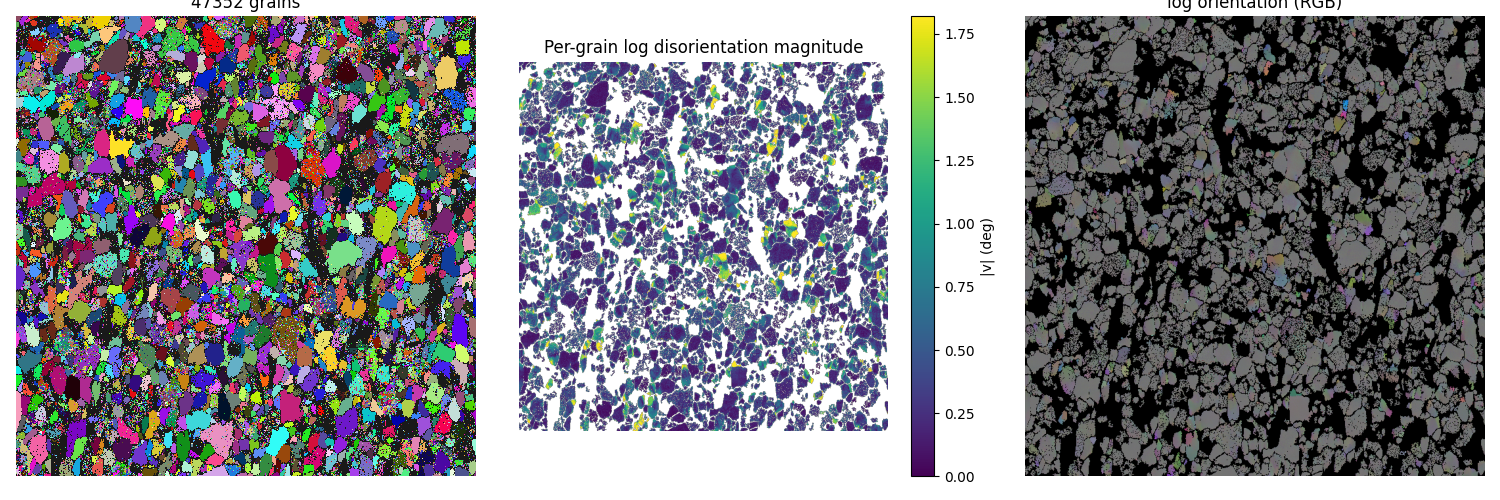

Grains flagged near FZ boundary: 0/1591


In [119]:
# ===== Visualize grains and per-grain log-orientation field =====
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Grain map (distinct colors, background dark)
rng = np.random.default_rng(0)
colors = np.vstack([[0.1, 0.1, 0.1], rng.random((grain_id.max() + 1, 3))])
gmap = colors[grain_id]
ax = axes[0]
ax.imshow(gmap, interpolation='nearest')
ax.set_title(f'{int(grain_id.max())} grains')
ax.axis('off')

# (b) Log-orientation magnitude
mag = np.linalg.norm(combined_log, axis=2)
mag[~combined_mask] = np.nan
ax = axes[1]
im = ax.imshow(np.rad2deg(mag), cmap='viridis', vmin=0, vmax=np.nanpercentile(np.rad2deg(mag), 98))
plt.colorbar(im, ax=ax, label='|v| (deg)')
ax.set_title('Per-grain log disorientation magnitude')
ax.axis('off')

# (c) RGB coding of log vector direction
lv = combined_log.copy()
lv -= lv.min()
lv /= (lv.max() + 1e-9)
lv[~combined_mask] = 0
ax = axes[2]
ax.imshow(lv)
ax.set_title('log orientation (RGB)')
ax.axis('off')

plt.tight_layout()
plt.show()

# FZ-boundary-warning grains
n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
print(f'Grains flagged near FZ boundary: {n_warn}/{len(grain_info)}')


## Optional grain-boundary mask (fallback for global reference)

In [120]:
# ===== Grain-boundary mask (OPTIONAL — for per-phase / global-reference fallback) =====
# With per-grain demean, v(x) is continuous across GBs by construction, so this is
# not strictly needed.  Kept as a fallback when running with a global reference, or
# to compare spectra with/without boundary contributions.

# ---- options ----
USE_GB_MASK = False               # False = no GB filter (per-grain demean regime)
GB_THETA_DEG = GRAIN_THETA_DEG    # reuse grain threshold
GB_CHAIN_FRAC = 0.5               # drop chains with >= this fraction of pixels inside GB mask
# -----------------

from scipy.ndimage import binary_dilation

def build_gb_mask(grain_id):
    """Binary mask of GB pixels: pixels where at least one 4-neighbor has a different grain id (or 0)."""
    gid = grain_id
    ny, nx = gid.shape
    m = np.zeros((ny, nx), dtype=bool)
    # Right / down neighbor mismatch
    m[:, :-1] |= (gid[:, :-1] != gid[:, 1:])
    m[:,  1:] |= (gid[:, :-1] != gid[:, 1:])
    m[:-1, :] |= (gid[:-1, :] != gid[1:, :])
    m[ 1:, :] |= (gid[:-1, :] != gid[1:, :])
    return m

def gb_mask_at_scale(base_mask, scale_px):
    """Dilate base GB mask by wavelet support at given scale."""
    r = max(1, int(np.ceil(scale_px)))
    return binary_dilation(base_mask, iterations=r)

if USE_GB_MASK:
    gb_base = build_gb_mask(grain_id)
    print(f'GB base mask: {gb_base.sum()} pixels ({100.0*gb_base.sum()/gb_base.size:.1f}%)')
else:
    gb_base = None
    print('GB chain filter disabled (per-grain demean makes v continuous across GBs).')


GB chain filter disabled (per-grain demean makes v continuous across GBs).


## Tensor WTMM on per-grain log field

In [121]:
# ===== Tensor WTMM on per-grain-demeaned log field =====
# CWT on combined per-grain log orientation field, tensor SVD at each scale,
# then WTMM on each SVD component.  Optional GB chain-level filter (scale-dilated).

from xsmurf_wrapper.anchor_chain import chain_and_extract
import xsmurf_wrapper as xsm

# ---- parameters ----
FRACINT_ALPHA = 1.5   # 0 = none; 0.5 mild, 1.0 strong, 2.0 very smooth
PAD           = 32
WTMM_METHOD='nms'
FOLLOW_VERSION='v1'
WAVELET       = 'mexican'
CHAIN_METHOD  = 'greedy'
THRESH        = 1e-4
A_MIN         = 1
N_OCT         = 4
N_VOX         = 20
SIMILITUDE    = 0.8
BORDER_PCT    = 1.0
DIST_FRAC     = 0.1
SMOOTH_CHAIN  = False    # chain spatial smoothing during chain_and_extract
# --------------------

# Wavelet scales
scales = compute_scales(n_oct=N_OCT, n_vox=N_VOX, a_min=A_MIN)
n_sc = len(scales)
ny, nx = combined_log.shape[:2]
px_um = ebsd.get('meta', {}).get('xstep', 1.0)

# Pseudo-fractional integration is applied as a per-scale coefficient
# rescaling W -> a**eta * W after the CWT (Wendt et al. 2009, Eq. 23).
# This preserves gradient direction and WTMM geometry while shifting
# tau(q) -> tau(q) + q*eta and h -> h + eta internally.  The reported
# spectra subtract Hstar*q / Hstar downstream to recover the original
# signal frame.
work_field = combined_log

# CWT on each of 3 components
print('CWT (3 components)...')
derivs = [cwt_2d_f32(work_field[..., c], scales, pad=PAD, derivs='first',
                     wavelet=WAVELET, verbose=False) for c in range(3)]

if FRACINT_ALPHA != 0:
    print(f'Pseudo-fractional integration eta={FRACINT_ALPHA} (coefficient rescaling)...')
    for c in range(3):
        for si, scale in enumerate(scales):
            f = np.float32(scale ** FRACINT_ALPHA)
            derivs[c]['dx'][si] *= f
            derivs[c]['dy'][si] *= f

# Tensor SVD at each scale.
# Four extrema modes (as in ebsdv4 / xsmurf tensor WTMM):
#   sigma_max : dominant SVD singular value (largest local strain magnitude)
#   sigma_min : smallest singular value    (weakest tensor direction)
#   modL      : longitudinal / symmetric strain channel
#               sqrt(gx1^2 + gy2^2 + 0.25*(gx2+gy1)^2 + gx3^2 + gy3^2)
#   modT      : transversal / antisymmetric shear channel
#               0.5 * |gx2 - gy1|
svd_fields = {
    'sigma_max': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'sigma_min': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'modL':      np.zeros((n_sc, ny, nx), dtype=np.float32),
    'modT':      np.zeros((n_sc, ny, nx), dtype=np.float32),
    'arg':       np.zeros((n_sc, ny, nx), dtype=np.float32),
}
print('Tensor SVD (2x3) + L/T decomposition...')
for si in range(n_sc):
    gx1, gy1 = derivs[0]['dx'][si], derivs[0]['dy'][si]
    gx2, gy2 = derivs[1]['dx'][si], derivs[1]['dy'][si]
    gx3, gy3 = derivs[2]['dx'][si], derivs[2]['dy'][si]
    smax, smin, arg = tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3)
    svd_fields['sigma_max'][si] = smax
    svd_fields['sigma_min'][si] = smin
    svd_fields['arg'][si] = arg
    svd_fields['modL'][si] = np.sqrt(
        gx1**2 + gy2**2 + 0.25 * (gx2 + gy1) ** 2 + gx3**2 + gy3**2
    ).astype(np.float32)
    svd_fields['modT'][si] = (0.5 * np.abs(gx2 - gy1)).astype(np.float32)

# Pick which modes to run WTMM on.  Any subset of
# ['sigma_max', 'sigma_min', 'modL', 'modT'].
SVD_MODES_RUN = ['sigma_max', 'sigma_min', 'modL', 'modT']
# Which mode downstream cells (partition, log-log, cumulants, viewer) use.
SVD_MODE_VIEW = 'sigma_max'
svd_wtmm = {}

for mode in SVD_MODES_RUN:
    print(f'\n  WTMM on {mode}...')
    mod = svd_fields[mode]
    arg = svd_fields['arg']
    ext_images = []
    for si, scale in enumerate(scales):
        dx_r = (mod[si] * np.cos(arg[si])).astype(np.float32)
        dy_r = (mod[si] * np.sin(arg[si])).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(dx_r),
            xsm.XImage.from_numpy(dy_r), scale, thresh=THRESH)
        ext_images.append(ext)

    chains = chain_and_extract(
        ext_images, scales, method=CHAIN_METHOD,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        similitude=SIMILITUDE, smooth=SMOOTH_CHAIN,
        border_percent=BORDER_PCT, dist_frac=DIST_FRAC)

    # ---- Optional GB chain filter ----
    if USE_GB_MASK and gb_base is not None:
        n_pre = len(chains)
        kept = []
        # cache dilated masks per scale
        scale_masks = {si: gb_mask_at_scale(gb_base, scales[si]) for si in range(n_sc)}
        for ch in chains:
            # evaluate fraction of chain pixels sitting inside the scale-appropriate mask
            xs = np.asarray(ch['x'], dtype=int)
            ys = np.asarray(ch['y'], dtype=int)
            # pick dilated mask at the chain's characteristic scale (use first anchor scale)
            si_anchor = int(np.argmin(np.abs(np.log2(scales) - ch['log2_scales'][0])))
            m = scale_masks[si_anchor]
            xs = np.clip(xs, 0, nx - 1)
            ys = np.clip(ys, 0, ny - 1)
            frac = m[ys, xs].mean() if len(xs) else 0.0
            if frac < GB_CHAIN_FRAC:
                kept.append(ch)
        chains = kept
        print(f'    GB chain filter: {n_pre} -> {len(chains)} chains (dropped {n_pre - len(chains)})')

    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders]

    # Label chains by grain
    chains_by_grain = {}
    for ch in chains:
        x0, y0 = int(ch['x'][0]), int(ch['y'][0])
        if 0 <= y0 < ny and 0 <= x0 < nx:
            gid0 = int(grain_id[y0, x0])
        else:
            gid0 = 0
        chains_by_grain.setdefault(gid0, []).append(ch)

    svd_wtmm[mode] = {
        'chains': chains, 'holders': holders,
        'chains_by_grain': chains_by_grain, 'mod': mod,
        'ext_images': ext_images,
    }
    if h_vals:
        print(f'    {len(chains)} chains, h median = {np.median(h_vals):.3f}')

print('\nDone.')


CWT (3 components)...
Pseudo-fractional integration eta=1.5 (coefficient rescaling)...
Tensor SVD (2x3) + L/T decomposition...

  WTMM on sigma_max...
    18476 chains, h median = 0.717

  WTMM on sigma_min...
    14141 chains, h median = 0.752

  WTMM on modL...
    17519 chains, h median = 0.710

  WTMM on modT...
    16786 chains, h median = 0.320

Done.


## Partition function $\mathcal{Z}(q,a)$ — Standard + Chainmax

In [ ]:
# ===== Partition function Z(q,a) with sample-variance error bars =====
# Standard + Chainmax.  Per-scale sample variances of Z_q, h(q,a), D(q,a)
# are computed from chain moments and propagated through weighted least squares,
# replacing the residual-based errors of extract_hq_Dq_from_plateaus.
#
# Why: with regression-residual errors, the bars measure FIT quality, not
# sampling variability -- they stay tiny for large |q| where the tails are
# actually severely undersampled.  Sample-variance bars correctly grow in the
# tail regime because Z(2q,a)/Z(q,a)^2 blows up when few chains dominate.

q_list_full = np.arange(-3, 6.1, 0.1)
n_q = len(q_list_full)
log2c = np.log(2.0)

def build_hd_from_chains(chains, scales_list):
    """Partition function + per-scale sample moments for WLS error propagation."""
    n_sc = len(scales_list)
    def _z(): return np.zeros((n_q, n_sc), dtype=np.float64)
    Zq_s, ZqL_s, Z2q_s, ZqL2_s = _z(), _z(), _z(), _z()
    Zq_c, ZqL_c, Z2q_c, ZqL2_c = _z(), _z(), _z(), _z()
    Na = np.zeros(n_sc, dtype=np.int64)

    for ch in chains:
        n_ch = len(ch['mod']); rm = 0.0
        for si in range(min(n_ch, n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0: continue
            Na[si] += 1
            lm = np.log(m)
            if m > rm: rm = m
            m_cx = rm; lm_cx = np.log(max(rm, 1e-30))
            for qi, q in enumerate(q_list_full):
                mq   = m ** q   if q != 0 else 1.0
                m2q  = m ** (2 * q) if q != 0 else 1.0
                mqc  = m_cx ** q if q != 0 else 1.0
                m2qc = m_cx ** (2 * q) if q != 0 else 1.0
                Zq_s [qi, si] += mq;   ZqL_s [qi, si] += mq * lm
                Z2q_s[qi, si] += m2q;  ZqL2_s[qi, si] += mq * lm * lm
                Zq_c [qi, si] += mqc;  ZqL_c [qi, si] += mqc * lm_cx
                Z2q_c[qi, si] += m2qc; ZqL2_c[qi, si] += mqc * lm_cx * lm_cx

    def _derive(Zq, ZqL, Z2q, ZqL2, Na_vec):
        tau = np.full_like(Zq, np.nan); h = np.full_like(Zq, np.nan); D = np.full_like(Zq, np.nan)
        sig_tau = np.full_like(Zq, np.nan)
        sig_h   = np.full_like(Zq, np.nan)
        sig_D   = np.full_like(Zq, np.nan)
        N2 = np.maximum(Na_vec, 1).astype(np.float64)[None, :]
        vZ = Zq > 0
        tau[vZ] = np.log(Zq[vZ]) / log2c
        h[vZ]   = ZqL[vZ] / (log2c * Zq[vZ])
        qmat = q_list_full[:, None]
        with np.errstate(invalid='ignore', divide='ignore'):
            D[vZ] = (qmat * np.ones_like(Zq))[vZ] * ZqL[vZ] / (Zq[vZ] * log2c) - np.log(Zq[vZ]) / log2c

        # Sample variance of Z_q (chains i.i.d. at each scale, given N fixed)
        var_Zq = np.maximum(Z2q - Zq * Zq / N2, 0.0)
        sig_tau_sv = np.sqrt(var_Zq) / (Zq * log2c)
        # Shot-noise floor: chain count itself fluctuates ~sqrt(N) across realizations.
        # At q=0 the within-realization variance collapses to zero (every m^0 = 1),
        # so without this floor weights blow up and the fit wobbles near q=0,
        # producing a spurious spike in C(q) = -d^2 tau / dq^2.  Adding in quadrature.
        sig_tau_shot = 1.0 / np.sqrt(N2) / log2c
        sig_tau[vZ] = np.sqrt(sig_tau_sv[vZ] ** 2
                              + (sig_tau_shot * np.ones_like(Zq))[vZ] ** 2)

        # Canonical-average variance via tilted distribution + effective sample size
        Neff = np.where(Z2q > 0, Zq * Zq / np.maximum(Z2q, 1e-300), 1.0)
        with np.errstate(invalid='ignore', divide='ignore'):
            var_q_logm = (ZqL2 / np.maximum(Zq, 1e-300)
                          - (ZqL / np.maximum(Zq, 1e-300)) ** 2)
        var_q_logm = np.maximum(var_q_logm, 0.0)
        sig_h[vZ] = np.sqrt(var_q_logm[vZ] / np.maximum(Neff[vZ], 1.0)) / log2c

        # sigma(D): quadrature (ignores Cov(h, log2 Z))
        sig_D[vZ] = np.sqrt((qmat * np.ones_like(Zq))[vZ] ** 2 * sig_h[vZ] ** 2
                            + sig_tau[vZ] ** 2)

        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
                'sigma_tau_qa': sig_tau, 'sigma_h_qa': sig_h, 'sigma_D_qa': sig_D,
                'N_a': Na_vec,
                'q_list': q_list_full,
                'scales': np.array(scales_list),
                'log2_scales': np.log2(np.array(scales_list))}

    return (_derive(Zq_s, ZqL_s, Z2q_s, ZqL2_s, Na),
            _derive(Zq_c, ZqL_c, Z2q_c, ZqL2_c, Na))


from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus as _xsm_extract

def fit_hq_Dq_weighted(hd, scale_range):
    """tau(q), h(q), D(q) over [smin, smax] (PIXEL units) with sample-variance-
    propagated error bars.

    - VALUES (tau, h, D): taken directly from xsmurf_wrapper.extract_hq_Dq_from_plateaus
      -- identical to the original pipeline, so tau(q) stays smooth and C(q)
      from finite differences behaves.
    - ERRORS (tau_err, h_err, D_err): replaced by propagation of per-scale
      sample-variance sigma through the OLS slope formula
          Var(slope) = sum (x_i - xbar)^2 sigma_i^2 / (sum (x_i - xbar)^2)^2
      Far more honest than the library's residual-based bars; grows correctly
      in the heavy-tail regime at large |q|.
    """
    # 1. Library values -- preserves original smooth tau/h/D
    res = _xsm_extract(hd, scale_range=scale_range)
    res = dict(res)  # avoid mutating library output

    # 2. Sample-variance-propagated error bars
    q_list = hd['q_list']
    scales = hd['scales']; log2_s = hd['log2_scales']
    smin, smax = scale_range
    mask = (scales >= smin) & (scales <= smax)
    x = log2_s[mask]
    if x.size >= 3:
        xm = x.mean(); dx = x - xm
        denom = float((dx * dx).sum())
        if denom > 0:
            for key_sig, err_key in [
                ('sigma_tau_qa', 'tau_err'),
                ('sigma_h_qa',   'h_err'),
                ('sigma_D_qa',   'D_err'),
            ]:
                n_q = len(q_list)
                new_err = np.full(n_q, np.nan)
                for qi in range(n_q):
                    s = hd[key_sig][qi, mask]
                    v = np.isfinite(s) & (s > 0)
                    if v.sum() >= 3:
                        var_slope = float((dx[v] * dx[v] * s[v] * s[v]).sum()) / (denom * denom)
                        new_err[qi] = float(np.sqrt(max(var_slope, 0.0)))
                res[err_key] = new_err
    return res


# ---- Run (per SVD mode) ----
hd_std_per_mode  = {}
hd_cmax_per_mode = {}
for _m in SVD_MODES_RUN:
    if _m not in svd_wtmm: continue
    _ch = svd_wtmm[_m]['chains']
    print(f'[{_m}] building partition function from {len(_ch)} chains, {len(scales)} scales...')
    _hs, _hc = build_hd_from_chains(_ch, scales)
    for _h in (_hs, _hc):
        _h['scales_um']      = np.array(scales) * px_um
        _h['log2_scales_um'] = np.log2(_h['scales_um'])
    hd_std_per_mode[_m]  = _hs
    hd_cmax_per_mode[_m] = _hc

# Legacy single-mode refs (downstream cells that still use a single mode)
hd_std  = hd_std_per_mode[SVD_MODE_VIEW]
hd_cmax = hd_cmax_per_mode[SVD_MODE_VIEW]

print('Done.  hd_{std,cmax}_per_mode[mode] -- sigma fields for WLS error propagation.')
print('Use fit_hq_Dq_weighted(hd, (smin_px, smax_px)) for spectra + sample-var error bars.')


Building partition function from 8813 chains, 80 scales...
Done.  hd_std / hd_cmax dicts carry sigma fields for WLS error propagation.
Use fit_hq_Dq_weighted(hd, (smin_px, smax_px)) for spectra + sample-var error bars.


## WTMM extrema log-log: chain modulus vs scale

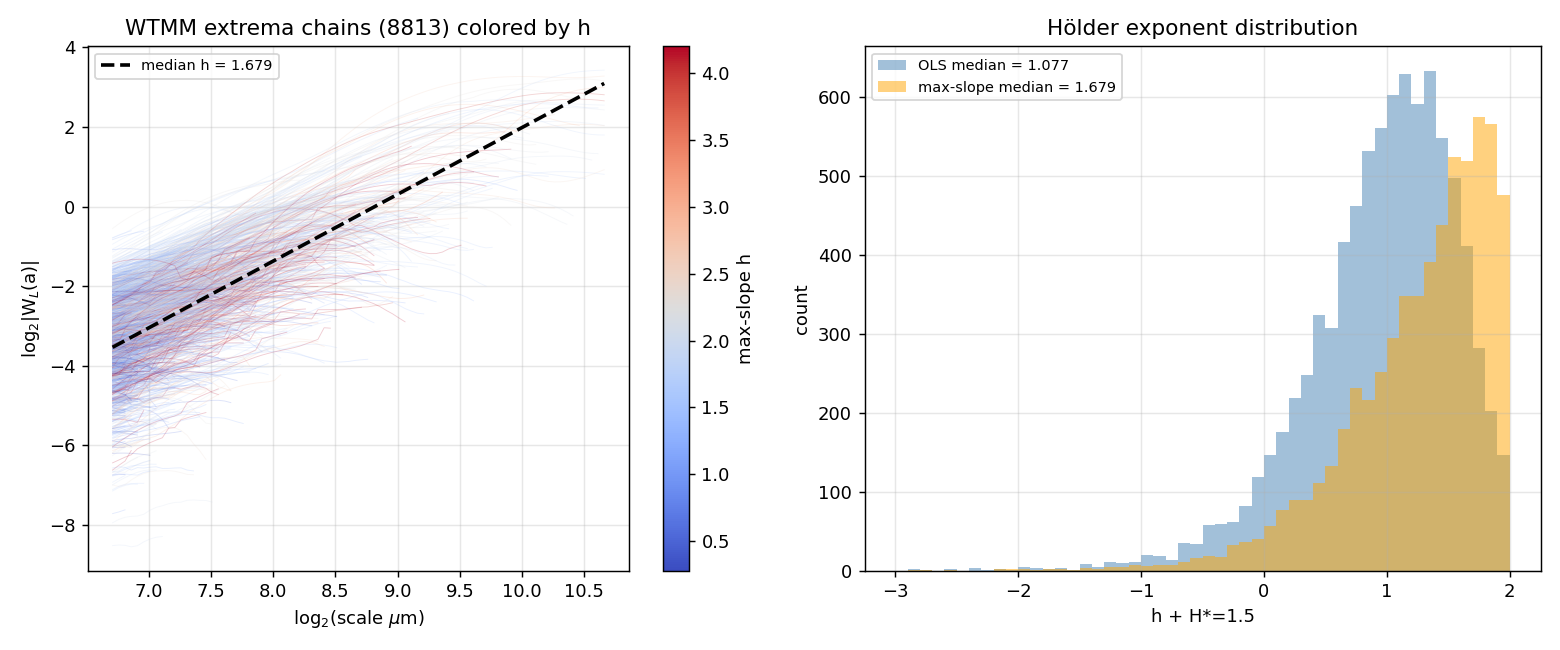

8813 chains, 8813 with valid max-slope, 8813 with OLS slope


In [ ]:
# ===== Extrema log-log plot: chain |W_L(a)| vs scale =====
# Interactive: SVD-mode dropdown switches between sigma_max / sigma_min / modL / modT.
# Each chain = one line; color = local max-slope Holder estimate.

%matplotlib widget
import matplotlib.pyplot as plt
from ipywidgets import interactive, Dropdown

def _max_slope(ch):
    log2s = ch['log2_scales']; log2m = ch['log2_mod']
    if len(log2s) < 2: return np.nan
    ds = np.diff(log2s); dm = np.diff(log2m)
    slopes = dm / ds
    v = np.isfinite(slopes)
    return float(np.max(slopes[v])) if v.any() else np.nan

_loglog_modes = [m for m in SVD_MODES_RUN if m in svd_wtmm]
_loglog_cache = {}
def _loglog_data(mode):
    if mode in _loglog_cache: return _loglog_cache[mode]
    chs       = svd_wtmm[mode]['chains']
    maxh_list = [_max_slope(ch) for ch in chs]
    maxh_lookup = {(int(ch['x'][0]), int(ch['y'][0])): h for ch, h in zip(chs, maxh_list)}
    maxh_valid = [h for h in maxh_list if np.isfinite(h)]
    h_ols      = [h['h'] for h in svd_wtmm[mode]['holders']]
    _loglog_cache[mode] = (chs, maxh_lookup, maxh_valid, h_ols)
    return _loglog_cache[mode]

_fig_ll, _axes_ll = plt.subplots(1, 2, figsize=(12, 5), dpi=130)
log2_s_um = np.log2(np.array(scales) * px_um)

def draw_loglog(svd_mode):
    chs, maxh_lookup, maxh_valid, h_ols = _loglog_data(svd_mode)
    for ax in _axes_ll: ax.cla()

    # left: chain log-log
    ax = _axes_ll[0]
    if maxh_valid:
        vmin, vmax = np.percentile(maxh_valid, [5, 95])
        cm = plt.cm.coolwarm; nm = plt.Normalize(vmin, vmax)
        for ch in chs[:2000]:
            if len(ch['mod']) < 3: continue
            hkey = (int(ch['x'][0]), int(ch['y'][0]))
            h = maxh_lookup.get(hkey, np.nan)
            if not np.isfinite(h): continue
            ax.plot(ch['log2_scales'] + np.log2(px_um), ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s_um) // 2
        mods_mid = [ch['log2_mod'][min(mid, len(ch['mod']) - 1)]
                    for ch in chs if len(ch['mod']) > mid]
        if mods_mid:
            h_med = float(np.median(maxh_valid))
            ax.plot(log2_s_um,
                    h_med * (log2_s_um - log2_s_um[mid]) + np.median(mods_mid),
                    'k--', lw=2, label=f'median h = {h_med:.3f}')
            ax.legend(fontsize=8)
        sm = plt.cm.ScalarMappable(cmap=cm, norm=nm); sm.set_array([])
        # Colorbar: only (re)attach if not already present on this axes
        if not getattr(ax, '_ll_cbar_done', False):
            plt.colorbar(sm, ax=ax, label='max-slope h')
            ax._ll_cbar_done = True
    ax.set(xlabel=r'log$_2$(scale $\mu$m)', ylabel=r'log$_2$|W$_L$(a)|',
           title=f'[{svd_mode}] WTMM chains ({len(chs)}) colored by h')
    ax.grid(True, alpha=0.3)

    # right: Holder histograms
    ax = _axes_ll[1]
    if h_ols:
        ax.hist(h_ols, bins=50, range=(-3, 2), alpha=0.5,
                label=f'OLS median = {np.median(h_ols):.3f}', color='steelblue')
    if maxh_valid:
        ax.hist(maxh_valid, bins=50, range=(-3, 2), alpha=0.5,
                label=f'max-slope median = {np.median(maxh_valid):.3f}',
                color='orange')
    hstar_label = f' + H*={FRACINT_ALPHA}' if FRACINT_ALPHA > 0 else ''
    ax.set(xlabel=f'h{hstar_label}', ylabel='count',
           title=f'[{svd_mode}] Holder exponent distribution')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    _fig_ll.tight_layout(); _fig_ll.canvas.draw_idle()
    print(f'[{svd_mode}] {len(chs)} chains, {len(maxh_valid)} valid max-slope, '
          f'{len(h_ols)} OLS slopes')

_loglog_interactive = interactive(
    draw_loglog,
    svd_mode=Dropdown(options=_loglog_modes, value=SVD_MODE_VIEW,
                      description='SVD mode:'),
)
display(_loglog_interactive)


## Cumulant analysis (Venugopal et al.) — interactive

ToggleButtons(description='PF:', options=('Standard', 'Chainmax'), value='Standard')

LEFT-click C0/C1 or C2/C3 = fit_min | RIGHT-click = fit_max


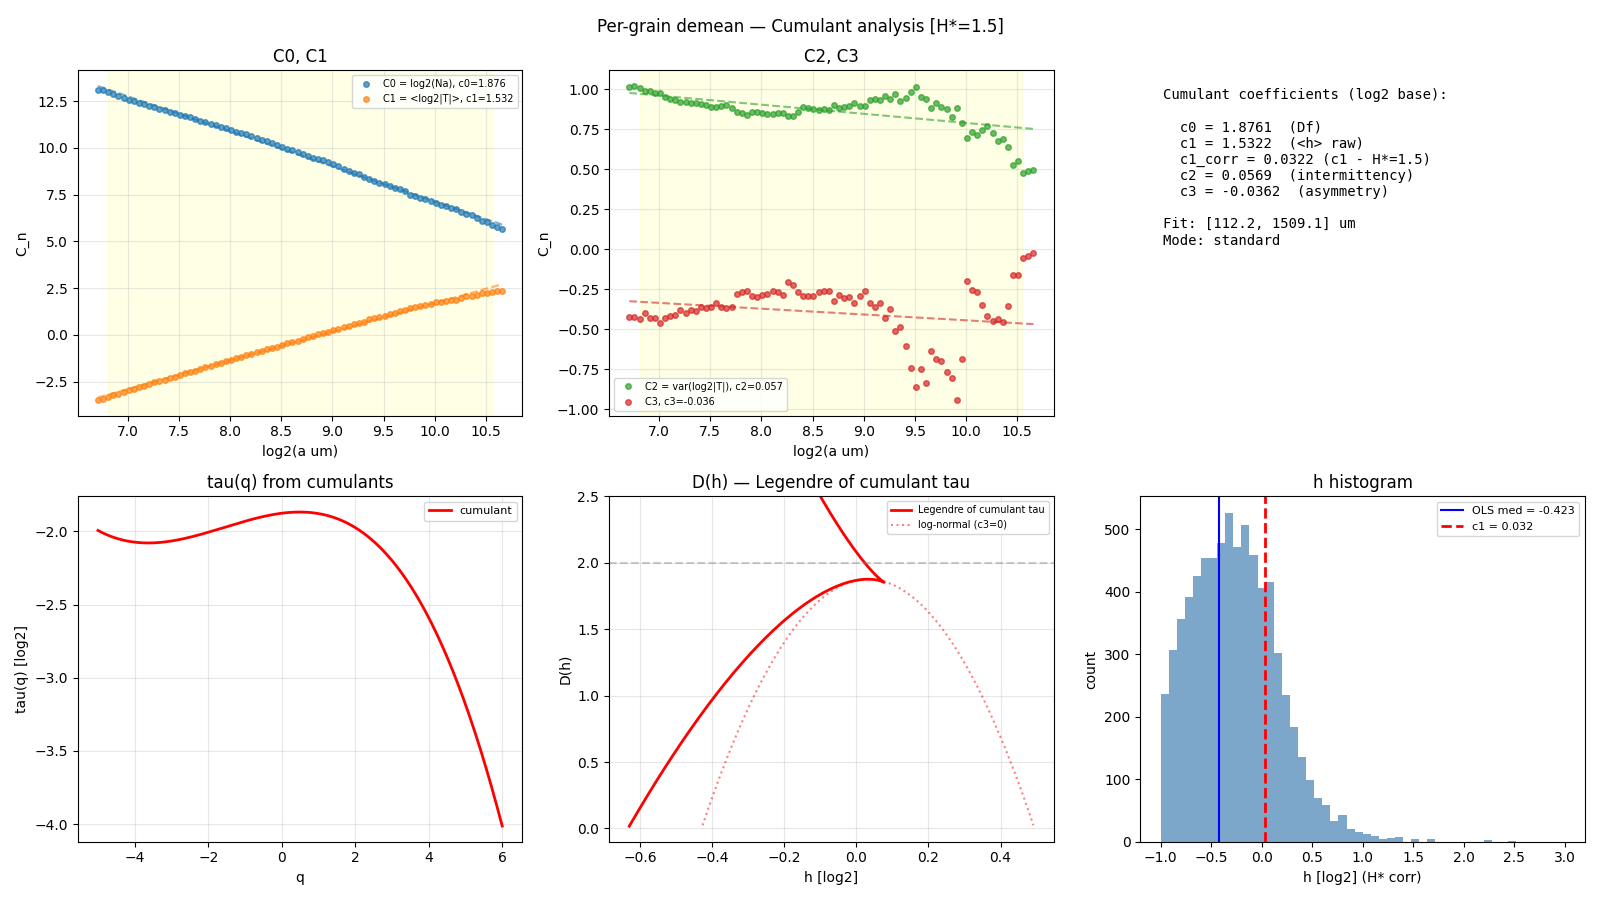

In [ ]:
# ===== Cumulant analysis (Venugopal et al. 2005) =====
# Psi_a(q) = ln<exp(q ln|T_a|)> = sum C_n(a) q^n / n!
# C_n(a) = (-1)^{n-1} c_n log(a)
# tau(q) = -c0 + c1 q - c2 q^2/2 + c3 q^3/6
# Interactive: SVD-mode dropdown; left-click cumulant panel = fit_min,
#              right-click = fit_max.  Each mode remembers its own range.

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets

def compute_cumulants_log2(chains, scales, use_chainmax=False):
    n_sc = len(scales)
    log2mod_per_scale = [[] for _ in range(n_sc)]
    for ch in chains:
        rm = 0.0
        for si in range(min(len(ch['mod']), n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0: continue
            if use_chainmax:
                if m > rm: rm = m
                m = rm
            log2mod_per_scale[si].append(np.log2(m))
    C = np.full((4, n_sc), np.nan)
    for si in range(n_sc):
        v = np.array(log2mod_per_scale[si])
        if len(v) < 5: continue
        C[0, si] = np.log2(len(v))
        C[1, si] = float(np.mean(v))
        C[2, si] = float(np.var(v))
        C[3, si] = float(np.mean((v - np.mean(v)) ** 3))
    return C

_cum_modes = [m for m in SVD_MODES_RUN if m in svd_wtmm]
scales_um  = np.array(scales) * px_um
log2_a     = np.log2(scales_um)

# Precompute C_std / C_cmax for every mode
cum_per_mode = {}
for _m in _cum_modes:
    _ch = svd_wtmm[_m]['chains']
    cum_per_mode[_m] = {
        'C_std':  compute_cumulants_log2(_ch, scales, use_chainmax=False),
        'C_cmax': compute_cumulants_log2(_ch, scales, use_chainmax=True),
    }

# Per-mode fit ranges (independent for each SVD channel!)
cum_state = {m: {
    'fit_min': scales_um[2]  if len(scales_um) > 2 else scales_um[0],
    'fit_max': scales_um[-3] if len(scales_um) > 3 else scales_um[-1],
} for m in _cum_modes}

cum_mode_dd  = widgets.Dropdown(options=_cum_modes, value=SVD_MODE_VIEW,
                                description='SVD mode:')
cum_cmax_tog = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
                                     value='Standard', description='PF:')

_fig_cum, _axes_cum = plt.subplots(2, 3, figsize=(16, 9))

def _cum_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in [_axes_cum[0, 0], _axes_cum[0, 1]]: return
    mode = cum_mode_dd.value
    st = cum_state[mode]
    a_val = 2.0 ** event.xdata
    if event.button == 1:   st['fit_min'] = a_val
    elif event.button == 3: st['fit_max'] = a_val
    if st['fit_min'] > st['fit_max']:
        st['fit_min'], st['fit_max'] = st['fit_max'], st['fit_min']
    cum_draw()
_fig_cum.canvas.mpl_connect('button_press_event', _cum_click)

def cum_draw(*_):
    mode    = cum_mode_dd.value
    use_cmax = 'Chainmax' in cum_cmax_tog.value
    Cset    = cum_per_mode[mode]
    C       = Cset['C_cmax'] if use_cmax else Cset['C_std']
    st      = cum_state[mode]
    fmin, fmax = st['fit_min'], st['fit_max']
    fmask   = (scales_um >= fmin) & (scales_um <= fmax)

    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c = {}; slopes = {}
    for n in range(4):
        y = C[n]; v = np.isfinite(y) & fmask
        if v.sum() < 3:
            c[n] = np.nan; slopes[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[v], y[v], 1)
        slopes[n] = sl
        c[n] = sign_map[n] * sl

    c0, c1, c2, c3 = c[0], c[1], c[2], c[3]
    c2_abs = abs(c2) if np.isfinite(c2) else 0.001
    Hstar = FRACINT_ALPHA
    c1_corr = c1 - Hstar if np.isfinite(c1) else np.nan

    for ax in _axes_cum.flat: ax.cla()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    names_c = ['C0 = log2(Na)', 'C1 = <log2|T|>', 'C2 = var(log2|T|)', 'C3']

    ax = _axes_cum[0, 0]
    for n in [0, 1]:
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=colors[n], ms=4, alpha=0.7,
                    label=f'{names_c[n]}, c{n}={c[n]:.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v],
                        slopes[n] * log2_a[v]
                        + (np.mean(y[vm]) - slopes[n] * np.mean(log2_a[vm])),
                        '--', color=colors[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.1, color='yellow')
    ax.set(xlabel='log2(a um)', ylabel='C_n', title=f'[{mode}] C0, C1')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_cum[0, 1]
    for n in [2, 3]:
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=colors[n], ms=4, alpha=0.7,
                    label=f'{names_c[n]}, c{n}={c[n]:.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v],
                        slopes[n] * log2_a[v]
                        + (np.mean(y[vm]) - slopes[n] * np.mean(log2_a[vm])),
                        '--', color=colors[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.1, color='yellow')
    ax.set(xlabel='log2(a um)', ylabel='C_n', title=f'[{mode}] C2, C3')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_cum[0, 2]; ax.axis('off')
    txt  = f'[{mode}] Cumulant coefficients (log2 base):\n\n'
    txt += f'  c0 = {c0:.4f}  (Df)\n'
    txt += f'  c1 = {c1:.4f}  (<h> raw)\n'
    if Hstar > 0: txt += f'  c1_corr = {c1_corr:.4f} (c1 - H*={Hstar})\n'
    txt += f'  c2 = {c2:.4f}  (intermittency)\n'
    txt += f'  c3 = {c3:.4f}  (asymmetry)\n\n'
    txt += f'Fit: [{fmin:.1f}, {fmax:.1f}] um\n'
    txt += f'Mode: {"chainmax" if use_cmax else "standard"}\n\n'
    # Show all modes' ranges so user sees what's remembered
    txt += 'Remembered ranges:\n'
    for _m in _cum_modes:
        s = cum_state[_m]
        mark = ' <--' if _m == mode else ''
        txt += f'  {_m}: [{s["fit_min"]:.1f}, {s["fit_max"]:.1f}]{mark}\n'
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top',
            fontsize=9, family='monospace')

    ax = _axes_cum[1, 0]
    q_arr = np.linspace(-5, 6, 300)
    tau_cum = -c0 + c1_corr * q_arr - c2_abs * q_arr ** 2 / 2 + c3 * q_arr ** 3 / 6
    if np.any(np.isfinite(tau_cum)):
        ax.plot(q_arr, tau_cum, 'r-', lw=2, label='cumulant')
    ax.set(xlabel='q', ylabel='tau(q) [log2]', title='tau(q) from cumulants')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = _axes_cum[1, 1]
    q_leg = np.linspace(-5, 6, 500)
    h_leg   = c1_corr - c2_abs * q_leg + c3 * q_leg ** 2 / 2
    tau_leg = -c0 + c1_corr * q_leg - c2_abs * q_leg ** 2 / 2 + c3 * q_leg ** 3 / 6
    D_leg   = q_leg * h_leg - tau_leg
    show = (D_leg >= 0) & np.isfinite(h_leg) & np.isfinite(D_leg)
    if show.any():
        ax.plot(h_leg[show], D_leg[show], 'r-', lw=2,
                label='Legendre of cumulant tau')
    if c2_abs > 1e-10:
        dh_sp = np.sqrt(2 * c0 * c2_abs) if c0 * c2_abs > 0 else 1.0
        h_par = np.linspace(c1_corr - dh_sp * 1.05, c1_corr + dh_sp * 1.05, 300)
        D_par = c0 - (h_par - c1_corr) ** 2 / (2 * c2_abs)
        D_par = np.where(D_par >= 0, D_par, np.nan)
        ax.plot(h_par, D_par, 'r:', lw=1.5, alpha=0.5, label='log-normal (c3=0)')
    ax.axhline(2, color='gray', ls='--', alpha=0.4)
    ax.set(xlabel='h [log2]', ylabel='D(h)',
           title='D(h) -- Legendre of cumulant tau', ylim=(-0.1, 2.5))
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_cum[1, 2]
    if len(h_ols := [h['h'] for h in svd_wtmm[mode]['holders']]):
        h_vals = np.array(h_ols) - Hstar
        ax.hist(h_vals, bins=50, range=(-1, 3), alpha=0.7, color='steelblue')
        ax.axvline(np.median(h_vals), color='blue', lw=1.5,
                   label=f'OLS med = {np.median(h_vals):.3f}')
    if np.isfinite(c1_corr):
        ax.axvline(c1_corr, color='red', ls='--', lw=2,
                   label=f'c1 = {c1_corr:.3f}')
    ax.set(xlabel='h [log2]' + (' (H* corr)' if Hstar > 0 else ''),
           ylabel='count', title=f'[{mode}] h histogram')
    ax.legend(fontsize=8)

    _fig_cum.suptitle(f'[{mode}] Per-grain demean -- Cumulant analysis'
                      + (f' [H*={Hstar}]' if Hstar > 0 else ''), fontsize=12)
    _fig_cum.tight_layout(); _fig_cum.canvas.draw_idle()

cum_cmax_tog.observe(cum_draw, names='value')
cum_mode_dd.observe(cum_draw,  names='value')
display(widgets.HBox([cum_mode_dd, cum_cmax_tog]))
print('LEFT-click C0/C1 or C2/C3 = fit_min | RIGHT-click = fit_max')
print('Switching SVD mode remembers per-mode ranges.')
cum_draw()


## Interactive PF fit: Dupont polynomial vs Venugopal cumulants

Click sets Regime I or II. LEFT-click = scale_min | RIGHT-click = scale_max


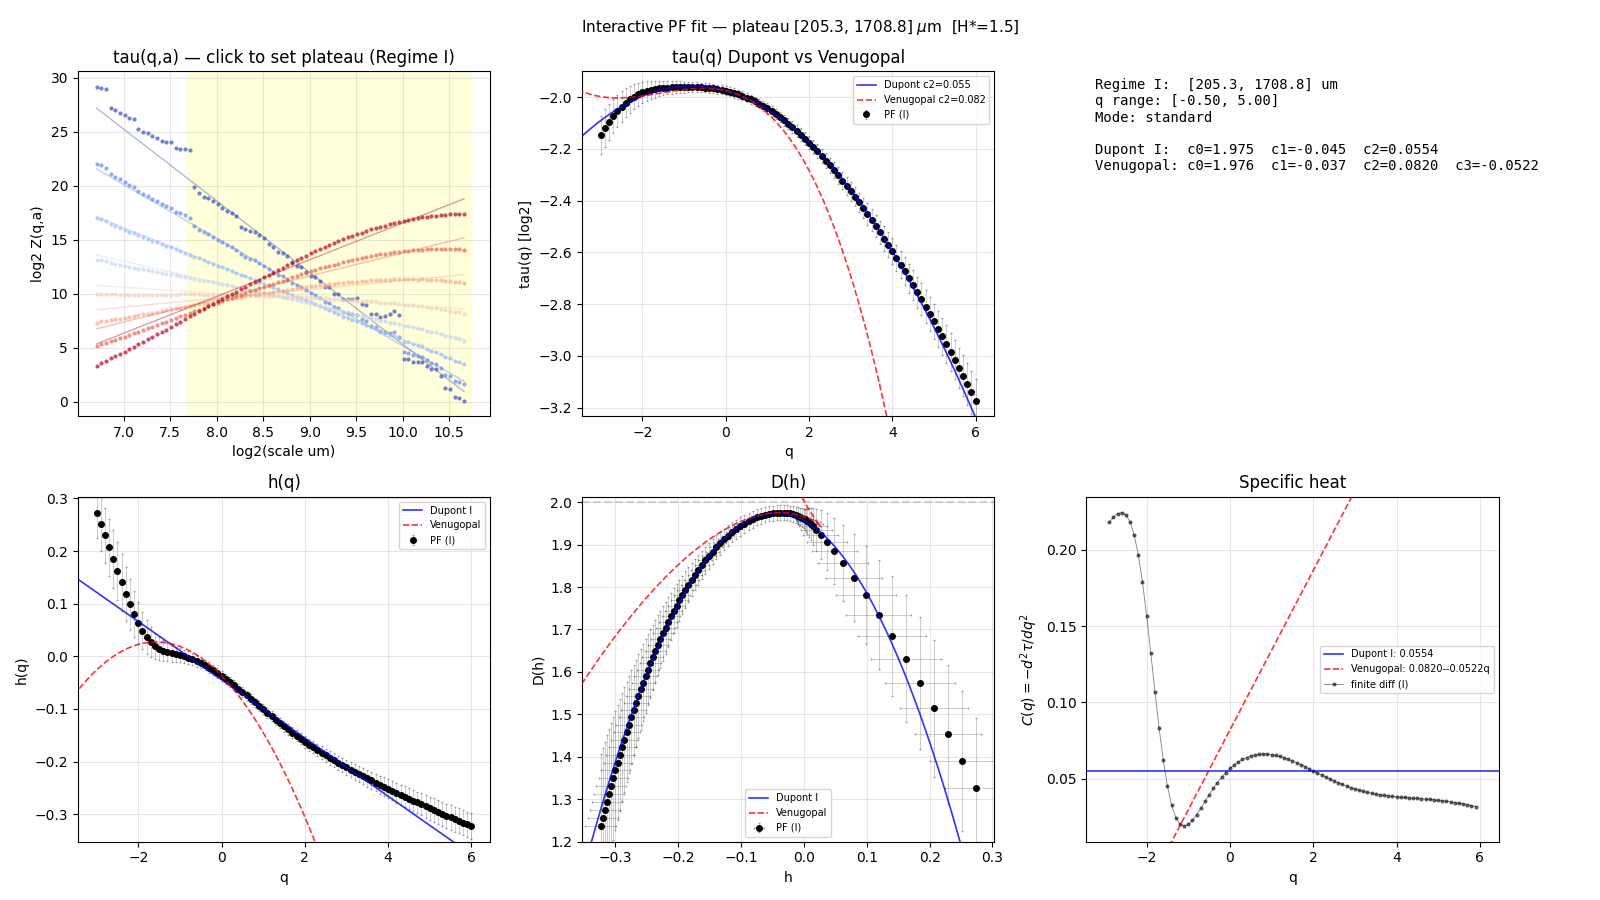

In [ ]:
# ===== Interactive partition-function fit: Dupont polynomial vs Venugopal cumulant =====
# SVD-mode dropdown; per-mode plateau state. Click log2 Z(q,a) panel to set
# Regime I / II plateau; slide q-range; toggle Standard/Chainmax.

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets

_pf_modes = [m for m in SVD_MODES_RUN if m in svd_wtmm
             and m in hd_std_per_mode and m in cum_per_mode]

# Per-mode plateau state; seeded from cum_state (cumulant cell).
# Once the user clicks this panel, that mode stops mirroring cum_state.
def _init_pf_state_for(mode):
    cs = cum_state.get(mode, {})
    return {
        'scale_min': cs.get('fit_min', scales_um[2]  if len(scales_um) > 2 else scales_um[0]),
        'scale_max': cs.get('fit_max', scales_um[-3] if len(scales_um) > 3 else scales_um[-1]),
        'scale_min_2': None, 'scale_max_2': None,
        'user_modified_I':  False,
        'user_modified_II': False,
        'qmin': -0.5, 'qmax': 5.0,     # per-mode Dupont fit q-range
    }
pf_state = {m: _init_pf_state_for(m) for m in _pf_modes}

pf_mode_dd    = widgets.Dropdown(options=_pf_modes, value=SVD_MODE_VIEW,
    description='SVD mode:')
pf_cmax_tog   = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
    value='Standard', description='PF:')
_init_qr = pf_state.get(SVD_MODE_VIEW, {'qmin': -0.5, 'qmax': 5.0})
pf_qrange     = widgets.FloatRangeSlider(
    value=[_init_qr['qmin'], _init_qr['qmax']],
    min=-5.0, max=6.0, step=0.25,
    description='q range:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px'))
pf_regime2_cb = widgets.Checkbox(value=False, description='Regime II',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='130px'))
pf_regime_sel = widgets.ToggleButtons(options=['I', 'II'], value='I',
    description='Click sets:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px'))

_fig_pf, _axes_pf = plt.subplots(2, 3, figsize=(16, 9))

def _pf_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes is not _axes_pf[0, 0]: return
    st = pf_state[pf_mode_dd.value]
    a = 2.0 ** event.xdata
    regime = pf_regime_sel.value
    if regime == 'I':
        st['user_modified_I'] = True
        if event.button == 1: st['scale_min'] = a
        elif event.button == 3: st['scale_max'] = a
        if st['scale_min'] > st['scale_max']:
            st['scale_min'], st['scale_max'] = st['scale_max'], st['scale_min']
    else:
        st['user_modified_II'] = True
        if event.button == 1: st['scale_min_2'] = a
        elif event.button == 3: st['scale_max_2'] = a
        if (st['scale_min_2'] and st['scale_max_2']
                and st['scale_min_2'] > st['scale_max_2']):
            st['scale_min_2'], st['scale_max_2'] = \
                st['scale_max_2'], st['scale_min_2']
    pf_draw()
_fig_pf.canvas.mpl_connect('button_press_event', _pf_click)

def _pf_range(*arrs, pad=0.05):
    vs = []
    for a in arrs:
        if a is None: continue
        v = np.asarray(a); v = v[np.isfinite(v)]
        if v.size: vs.append(v)
    if not vs: return None
    allv = np.concatenate(vs)
    lo, hi = float(allv.min()), float(allv.max())
    if hi - lo < 1e-9: return lo - 0.5, hi + 0.5
    p = pad * (hi - lo)
    return lo - p, hi + p

def pf_draw(*_):
    mode    = pf_mode_dd.value
    st      = pf_state[mode]
    use_cmax = 'Chainmax' in pf_cmax_tog.value
    Hstar = FRACINT_ALPHA

    # Until the user clicks this panel for this mode, mirror cum_state for it.
    if not st['user_modified_I']:
        cs = cum_state.get(mode, {})
        if 'fit_min' in cs and 'fit_max' in cs:
            st['scale_min'] = cs['fit_min']
            st['scale_max'] = cs['fit_max']

    hd = hd_cmax_per_mode[mode] if use_cmax else hd_std_per_mode[mode]
    log2_s = hd['log2_scales_um']
    scales_arr = hd['scales_um']
    smin, smax = st['scale_min'], st['scale_max']
    smin2, smax2 = st.get('scale_min_2'), st.get('scale_max_2')
    has_r2 = pf_regime2_cb.value and smin2 is not None and smax2 is not None
    s_mask  = (scales_arr >= smin)  & (scales_arr <= smax)
    s_mask2 = (scales_arr >= smin2) & (scales_arr <= smax2) if has_r2 else None

    res = fit_hq_Dq_weighted(hd, scale_range=(smin / px_um, smax / px_um))
    q_pf = res['q_list']
    tau_pf = res['tau'] - Hstar * q_pf
    tau_err = res['tau_err']
    h_pf   = res['h'] - Hstar
    h_err  = res['h_err']
    D_pf   = res['D']
    D_err  = res['D_err']
    valid  = np.isfinite(tau_pf) & np.isfinite(h_pf) & np.isfinite(D_pf)

    tau_pf2 = h_pf2 = D_pf2 = None; valid2 = None; res2 = None
    c0p2 = c1p2 = c2p2 = np.nan
    if has_r2:
        res2 = fit_hq_Dq_weighted(hd, scale_range=(smin2 / px_um, smax2 / px_um))
        tau_pf2 = res2['tau'] - Hstar * res2['q_list']
        h_pf2   = res2['h']  - Hstar
        D_pf2   = res2['D']
        valid2  = np.isfinite(tau_pf2) & np.isfinite(h_pf2) & np.isfinite(D_pf2)

    qmin, qmax = st['qmin'], st['qmax']
    fm = valid & (q_pf >= qmin) & (q_pf <= qmax)
    c0p = c1p = c2p = np.nan
    if fm.sum() >= 4:
        w = np.ones(fm.sum()); te = tau_err[fm]
        ge = np.isfinite(te) & (te > 0)
        if ge.any(): w[ge] = 1.0 / te[ge]
        pp = np.polyfit(q_pf[fm], tau_pf[fm], 2, w=w)
        c0p = -pp[2]; c1p = pp[1]; c2p = -2 * pp[0]

    # Venugopal cumulants (per-mode)
    Cset = cum_per_mode[mode]
    C = Cset['C_cmax'] if use_cmax else Cset['C_std']
    fmc = (scales_um >= smin) & (scales_um <= smax)
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c_ven = {}
    for n in range(4):
        y = C[n]; vv = np.isfinite(y) & fmc
        if vv.sum() < 3: c_ven[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[vv], y[vv], 1); c_ven[n] = sign_map[n] * sl
    c0v = c_ven[0]
    c1v = (c_ven[1] - Hstar) if np.isfinite(c_ven.get(1, np.nan)) else np.nan
    c2v = abs(c_ven[2]) if np.isfinite(c_ven.get(2, np.nan)) else np.nan
    c3v = c_ven.get(3, 0.0) if np.isfinite(c_ven.get(3, np.nan)) else 0.0

    for ax in _axes_pf.flat: ax.cla()

    ax = _axes_pf[0, 0]
    q_show = np.array([-3, -2, -1, 0, 1, 2, 3, 4])
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))
    for qv, color in zip(q_show, colors):
        idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
        y = hd['tau_qa'][idx]; v2 = np.isfinite(y)
        if v2.sum() < 2: continue
        ax.plot(log2_s[v2], y[v2], 'o', color=color, ms=3, alpha=0.7, mec='none')
        yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
        if vf.sum() >= 2:
            sl, ic = np.polyfit(xf[vf], yf[vf], 1)
            ax.plot(log2_s[v2], sl * log2_s[v2] + ic, '-', color=color, lw=1, alpha=0.4)
    ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
    if has_r2:
        ax.axvspan(np.log2(smin2), np.log2(smax2), alpha=0.15, color='cyan', zorder=0)
    ax.set(xlabel='log2(scale um)', ylabel='log2 Z(q,a)',
           title=f'[{mode}] tau(q,a) -- click sets Regime {pf_regime_sel.value}')
    ax.grid(True, alpha=0.3)

    ax = _axes_pf[0, 1]
    if valid.any():
        ax.errorbar(q_pf[valid], tau_pf[valid], yerr=tau_err[valid],
                    fmt='ko', ms=4, capsize=1, elinewidth=0.4,
                    ecolor=(0, 0, 0, 0.35), zorder=2, label='PF (I)')
    if has_r2 and valid2 is not None and valid2.any():
        ax.errorbar(res2['q_list'][valid2], tau_pf2[valid2],
                    yerr=res2['tau_err'][valid2],
                    fmt='s', mfc='none', mec='cyan', ms=5, capsize=1,
                    elinewidth=0.4, ecolor=(0, 1, 1, 0.45), zorder=2,
                    label='PF (II)')
    qd = np.linspace(-5, 6, 300)
    if np.isfinite(c0p):
        ax.plot(qd, -c0p + c1p * qd - c2p * qd ** 2 / 2, 'b-', lw=1.2,
                alpha=0.8, zorder=3, label=f'Dupont c2={c2p:.3f}')
    if np.isfinite(c0v):
        ax.plot(qd, -c0v + c1v * qd - c2v * qd ** 2 / 2 + c3v * qd ** 3 / 6,
                'r--', lw=1.2, alpha=0.8, zorder=3,
                label=f'Venugopal c2={c2v:.3f}')
    ax.set(xlabel='q', ylabel='tau(q) [log2]', title='tau(q) Dupont vs Venugopal')
    _q2 = res2['q_list'][valid2] if (has_r2 and valid2 is not None) else None
    _t2 = tau_pf2[valid2] if (has_r2 and valid2 is not None) else None
    _xr = _pf_range(q_pf[valid], _q2)
    _yr = _pf_range(tau_pf[valid], _t2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_pf[0, 2]; ax.axis('off')
    txt  = f'[{mode}]\n'
    txt += f'Regime I:  [{smin:.1f}, {smax:.1f}] um\n'
    if has_r2: txt += f'Regime II: [{smin2:.1f}, {smax2:.1f}] um\n'
    txt += f'q range: [{qmin:.2f}, {qmax:.2f}]\n'
    txt += f'Mode: {"chainmax" if use_cmax else "standard"}\n\n'
    txt += f'Dupont I:  c0={c0p:.3f}  c1={c1p:.3f}  c2={c2p:.4f}\n'
    txt += f'Venugopal: c0={c0v:.3f}  c1={c1v:.3f}  c2={c2v:.4f}'
    if np.isfinite(c3v): txt += f'  c3={c3v:.4f}'
    # Show per-mode remembered plateaus
    txt += '\n\nRemembered Regime I per mode:\n'
    for _m in _pf_modes:
        s = pf_state[_m]
        mark = ' <--' if _m == mode else ''
        mod_flag = '*' if s['user_modified_I'] else ' '
        txt += f' {mod_flag}{_m}: [{s["scale_min"]:.1f}, {s["scale_max"]:.1f}]{mark}\n'
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top',
            fontsize=9, family='monospace')

    c0p2 = c1p2 = c2p2 = np.nan
    if has_r2 and valid2 is not None:
        q2_r = res2['q_list']
        fm2 = valid2 & (q2_r >= qmin) & (q2_r <= qmax)
        if fm2.sum() >= 4:
            w2 = np.ones(fm2.sum()); te22 = res2['tau_err'][fm2]
            ge2 = np.isfinite(te22) & (te22 > 0)
            if ge2.any(): w2[ge2] = 1.0 / te22[ge2]
            pp2 = np.polyfit(q2_r[fm2], tau_pf2[fm2], 2, w=w2)
            c0p2 = -pp2[2]; c1p2 = pp2[1]; c2p2 = -2 * pp2[0]

    ax = _axes_pf[1, 0]
    if valid.any():
        ax.errorbar(q_pf[valid], h_pf[valid], yerr=h_err[valid],
                    fmt='ko', ms=4, capsize=1, elinewidth=0.4,
                    ecolor=(0, 0, 0, 0.35), zorder=2, label='PF (I)')
    if has_r2 and valid2 is not None and valid2.any():
        ax.errorbar(res2['q_list'][valid2], h_pf2[valid2], yerr=res2['h_err'][valid2],
                    fmt='s', mfc='none', mec='cyan', ms=5, capsize=1,
                    elinewidth=0.4, ecolor=(0, 1, 1, 0.45), zorder=2,
                    label='PF (II)')
    if np.isfinite(c1p) and np.isfinite(c2p):
        ax.plot(qd, c1p - c2p * qd, 'b-', lw=1.2, alpha=0.8, zorder=3, label='Dupont I')
    if np.isfinite(c1p2) and np.isfinite(c2p2):
        ax.plot(qd, c1p2 - c2p2 * qd, 'c-', lw=1.2, alpha=0.8, zorder=3, label='Dupont II')
    if np.isfinite(c1v) and np.isfinite(c2v):
        ax.plot(qd, c1v - c2v * qd + c3v * qd ** 2 / 2, 'r--', lw=1.2,
                alpha=0.8, zorder=3, label='Venugopal')
    ax.set(xlabel='q', ylabel='h(q)', title='h(q)')
    _h2 = h_pf2[valid2] if (has_r2 and valid2 is not None) else None
    _xr = _pf_range(q_pf[valid], _q2)
    _yr = _pf_range(h_pf[valid], _h2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_pf[1, 1]
    if valid.any():
        ax.errorbar(h_pf[valid], D_pf[valid], yerr=D_err[valid],
                    xerr=h_err[valid], fmt='ko', ms=4, capsize=1,
                    elinewidth=0.4, ecolor=(0, 0, 0, 0.35), zorder=2,
                    label='PF (I)')
    if has_r2 and valid2 is not None and valid2.any():
        ax.errorbar(h_pf2[valid2], D_pf2[valid2], yerr=res2['D_err'][valid2],
                    xerr=res2['h_err'][valid2],
                    fmt='s', mfc='none', mec='cyan', ms=5, capsize=1,
                    elinewidth=0.4, ecolor=(0, 1, 1, 0.45), zorder=2,
                    label='PF (II)')
    if np.isfinite(c0p) and c2p > 1e-6:
        ds = np.sqrt(2 * c0p * c2p) if c0p * c2p > 0 else 1.0
        hh = np.linspace(c1p - ds, c1p + ds, 300)
        dd = c0p - (hh - c1p) ** 2 / (2 * c2p)
        ax.plot(hh, np.where(dd >= 0, dd, np.nan), 'b-', lw=1.2, alpha=0.8,
                zorder=3, label='Dupont I')
    if np.isfinite(c0p2) and c2p2 > 1e-6:
        ds2 = np.sqrt(2 * c0p2 * c2p2) if c0p2 * c2p2 > 0 else 1.0
        hh2x = np.linspace(c1p2 - ds2, c1p2 + ds2, 300)
        dd2 = c0p2 - (hh2x - c1p2) ** 2 / (2 * c2p2)
        ax.plot(hh2x, np.where(dd2 >= 0, dd2, np.nan), 'c-', lw=1.2, alpha=0.8,
                zorder=3, label='Dupont II')
    if np.isfinite(c0v) and c2v > 1e-6:
        q_l = np.linspace(-5, 6, 500)
        h_l = c1v - c2v * q_l + c3v * q_l ** 2 / 2
        t_l = -c0v + c1v * q_l - c2v * q_l ** 2 / 2 + c3v * q_l ** 3 / 6
        D_l = q_l * h_l - t_l
        ok = (D_l >= 0) & np.isfinite(h_l)
        ax.plot(h_l[ok], D_l[ok], 'r--', lw=1.2, alpha=0.8, zorder=3, label='Venugopal')
    ax.axhline(2, color='gray', ls='--', alpha=0.3)
    ax.set(xlabel='h', ylabel='D(h)', title='D(h)')
    _D2 = D_pf2[valid2] if (has_r2 and valid2 is not None) else None
    _xr = _pf_range(h_pf[valid], _h2)
    _yr = _pf_range(D_pf[valid], _D2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_pf[1, 2]
    if np.isfinite(c2p):
        ax.axhline(c2p, color='blue', lw=1.2, alpha=0.8, zorder=3,
                   label=f'Dupont I: {c2p:.4f}')
    if np.isfinite(c2p2):
        ax.axhline(c2p2, color='cyan', lw=1.2, alpha=0.8, ls=':', zorder=3,
                   label=f'Dupont II: {c2p2:.4f}')
    if np.isfinite(c2v) and np.isfinite(c3v):
        ax.plot(qd, c2v - c3v * qd, 'r--', lw=1.2, alpha=0.8, zorder=3,
                label=f'Venugopal: {c2v:.4f}-{c3v:.4f}q')
    _cq_x = _cq_y = None
    _cq_x2 = _cq_y2 = None
    qfd = q_pf[valid]; tfd = tau_pf[valid]
    if len(qfd) >= 5:
        sr = np.argsort(qfd); qs = qfd[sr]; ts = tfd[sr]; dq = np.diff(qs)
        d2 = np.full(len(qs), np.nan)
        for k in range(1, len(qs) - 1):
            d2[k] = (ts[k + 1] - 2 * ts[k] + ts[k - 1]) / ((dq[k - 1] + dq[k]) / 2) ** 2
        fv = np.isfinite(d2)
        if fv.any():
            _cq_x, _cq_y = qs[fv], -d2[fv]
            ax.plot(_cq_x, _cq_y, 'ko-', ms=2, lw=0.6, alpha=0.5,
                    label='finite diff (I)')
    if has_r2 and valid2 is not None:
        qfd2 = res2['q_list'][valid2]; tfd2 = tau_pf2[valid2]
        if len(qfd2) >= 5:
            sr2 = np.argsort(qfd2); qs2 = qfd2[sr2]; ts2r = tfd2[sr2]; dq2 = np.diff(qs2)
            d22 = np.full(len(qs2), np.nan)
            for k in range(1, len(qs2) - 1):
                d22[k] = (ts2r[k + 1] - 2 * ts2r[k] + ts2r[k - 1]) / ((dq2[k - 1] + dq2[k]) / 2) ** 2
            fv2 = np.isfinite(d22)
            if fv2.any():
                _cq_x2, _cq_y2 = qs2[fv2], -d22[fv2]
                ax.plot(_cq_x2, _cq_y2, marker='s', mfc='none',
                        mec='cyan', ms=3, lw=0.6, alpha=0.6,
                        label='finite diff (II)')
    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set(xlabel='q', ylabel=r'$C(q) = -d^2\tau/dq^2$', title='Specific heat')
    _xr = _pf_range(q_pf[valid], _q2)
    _yr = _pf_range(_cq_y, _cq_y2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    _fig_pf.suptitle(f'[{mode}] Interactive PF fit -- plateau [{smin:.1f}, {smax:.1f}] $\\mu$m'
                     + (f'  [H*={Hstar}]' if Hstar > 0 else ''), fontsize=11)
    _fig_pf.tight_layout(); _fig_pf.canvas.draw_idle()

# Per-mode q-range sync: switching mode -> slider jumps to that mode's
# stored range; slider movement writes to current mode.  Flag guards recursion.
_pf_q_updating = {'v': False}
def _pf_on_mode_change(change):
    _pf_q_updating['v'] = True
    try:
        st = pf_state[change['new']]
        pf_qrange.value = (st['qmin'], st['qmax'])
    finally:
        _pf_q_updating['v'] = False
    pf_draw()
def _pf_on_qrange_change(change):
    if _pf_q_updating['v']: return
    st = pf_state[pf_mode_dd.value]
    st['qmin'], st['qmax'] = pf_qrange.value
    pf_draw()
pf_mode_dd.observe(_pf_on_mode_change, names='value')
pf_qrange.observe(_pf_on_qrange_change, names='value')
pf_cmax_tog.observe(pf_draw,   names='value')
pf_regime2_cb.observe(pf_draw, names='value')
pf_regime_sel.observe(pf_draw, names='value')
display(widgets.VBox([
    widgets.HBox([pf_mode_dd, pf_cmax_tog, pf_regime2_cb, pf_regime_sel]),
    pf_qrange,
]))
print('Click sets Regime I or II. LEFT-click = scale_min | RIGHT-click = scale_max')
print('Switching SVD mode remembers per-mode plateaus; * in summary = user-clicked.')
pf_draw()


## WTMMM maxima viewer (interactive) — with wavelet scalebar

In [ ]:
# ===== Precompute skeleton + partition data for WTMMM viewer =====
# Builds one precompute bundle per SVD mode in SVD_MODES_RUN so the viewer
# can toggle between sigma_max / sigma_min / modL / modT at display time.
from PIL import Image, ImageDraw
import matplotlib.patheffects as path_effects
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# ---- Wavelet-scalebar helpers (ported from ebsd_ps_ultra cell 20) ----
def _wavelet_shape(wavelet='gaussian', n_pts=301):
    x = np.linspace(-4, 4, n_pts)
    if wavelet == 'mexican': psi = x * (x ** 2 - 3) * np.exp(-x ** 2 / 2)
    else:                    psi = -x * np.exp(-x ** 2 / 2)
    psi /= np.max(np.abs(psi))
    return x, psi

def add_wavelet_scalebar(ax, scale, px_to_unit=1.0, unit_str='px',
                         wavelet='gaussian', loc='lower right',
                         pad_frac=0.04, fontsize=7, color='#39FF14'):
    x_unit, psi = _wavelet_shape(wavelet)
    bar_px = scale
    label_val = bar_px * px_to_unit
    imgs = ax.get_images()
    img_nx = int(imgs[0].get_array().shape[1]) if imgs else 512
    img_ny = int(imgs[0].get_array().shape[0]) if imgs else 512
    bar_frac = min(bar_px / img_nx, 0.40)
    margin = pad_frac
    max_bar = (1 - 2 * margin) / 4.0
    bar_frac = min(bar_frac, max_bar)
    bcx = 1 - margin - 2 * bar_frac if 'right' in loc else margin + 2 * bar_frac
    wamp_frac = max(min(bar_px / img_ny * 0.5, 0.06), 0.015)
    label_y = margin
    wcy = label_y + 0.04 + wamp_frac
    fxc = [path_effects.withStroke(linewidth=2.5, foreground='black')]
    fxt = [path_effects.withStroke(linewidth=2.0, foreground='black')]
    wx = np.array([bcx + xv / 2.0 * bar_frac for xv in x_unit])
    wy = np.array([wcy + p * wamp_frac for p in psi])
    cl = (wx >= margin) & (wx <= 1 - margin)
    if cl.any():
        ax.plot(wx[cl], wy[cl], color=color, lw=1.4, transform=ax.transAxes,
                zorder=11, clip_on=False, path_effects=fxc)
    if label_val >= 100:   lbl = f'{label_val:.0f} {unit_str}'
    elif label_val >= 10:  lbl = f'{label_val:.1f} {unit_str}'
    else:                  lbl = f'{label_val:.2f} {unit_str}'
    ax.text(bcx, label_y, lbl, ha='center', va='bottom', fontsize=fontsize,
            color=color, fontweight='bold', transform=ax.transAxes,
            zorder=13, clip_on=False, path_effects=fxt)

# IPF colour fallback (pergrain notebook has no ipf_color_cubic)
if 'ipf_color_cubic' not in globals():
    def ipf_color_cubic(e1, e2, e3, sample_dir='Z'):
        ny, nx = e1.shape
        rgb = np.zeros((ny, nx, 3), dtype=np.float64)
        rgb[..., 0] = (e1 % 360.0) / 360.0
        rgb[..., 1] = (e2 % 180.0) / 180.0
        rgb[..., 2] = (e3 % 360.0) / 360.0
        return rgb

if 'svd_wtmm' not in globals() or not svd_wtmm:
    raise RuntimeError('Run the Tensor WTMM cell first to produce svd_wtmm.')

nps = len(scales)
q_pf_global = np.arange(-1, 8.1, 0.1)
n_q_pf = len(q_pf_global)
q0_mask_global = (q_pf_global == 0)

def _precompute_mode(mode):
    """Build the full viewer bundle for one SVD mode."""
    ext_images      = svd_wtmm[mode]['ext_images']
    chains          = svd_wtmm[mode]['chains']
    holders         = svd_wtmm[mode]['holders']
    filtered_chains = chains

    # chainmax lookup
    chainmax = [{} for _ in range(nps)]
    for ch in filtered_chains:
        rm = 0.0
        for si in range(min(len(ch['mod']), nps)):
            m = abs(float(ch['mod'][si]))
            if m > rm: rm = m
            chainmax[si][(int(ch['x'][si]), int(ch['y'][si]))] = rm

    filtered_positions = set()
    for ch in filtered_chains:
        n = len(ch['mod'])
        for si in range(min(n, nps)):
            filtered_positions.add((si, int(ch['x'][si]), int(ch['y'][si])))

    h_fit_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders}

    chain_lookup = {}
    for ch in chains:
        vc_len = len(ch['mod'])
        if vc_len == 0: continue
        anchor = (int(ch['x'][0]), int(ch['y'][0]))
        for si in range(min(vc_len, nps)):
            chain_lookup[(si, int(ch['x'][si]), int(ch['y'][si]))] = (vc_len, anchor)

    _use_filt = len(filtered_positions) > 0
    surviving_wtmmm = set() if _use_filt else None
    if _use_filt:
        for ch in filtered_chains:
            n = len(ch['mod'])
            for si in range(min(n, nps)):
                surviving_wtmmm.add((si, int(ch['x'][si]), int(ch['y'][si])))

    skel_chains = []
    for ch in chains:
        n = len(ch['mod'])
        if n < 3: continue
        if _use_filt:
            in_filter = any((si, int(ch['x'][si]), int(ch['y'][si])) in filtered_positions
                            for si in range(min(n, nps)))
            if not in_filter: continue
        mods = np.maximum(np.abs(ch['mod']).astype(np.float64), 1e-30)
        skel_chains.append({
            'log2_s': np.log2(np.array(scales[:n])),
            'log2_m': np.log2(mods), 'mod': mods, 'n': n,
            'x0': int(ch['x'][0]), 'y0': int(ch['y'][0]),
            'x': ch['x'], 'y': ch['y'],
        })
    n_ch = len(skel_chains)
    chain_n = np.array([sc['n'] for sc in skel_chains], dtype=np.int32)

    mod_matrix = np.full((n_ch, nps), np.nan, dtype=np.float64)
    for ci, sc in enumerate(skel_chains):
        mod_matrix[ci, :sc['n']] = sc['mod']
    mod_safe = np.where(np.isnan(mod_matrix), np.nan, np.maximum(mod_matrix, 1e-30))
    log2_mod_matrix = np.log2(mod_safe)
    valid_mask = ~np.isnan(mod_safe)
    running_max_matrix = np.full_like(mod_safe, np.nan)
    for ci in range(n_ch):
        n_val = chain_n[ci]
        if n_val > 0:
            running_max_matrix[ci, :n_val] = np.maximum.accumulate(mod_safe[ci, :n_val])
    log2_running_max_matrix = np.log2(running_max_matrix)

    wt_x_by_scale = []; wt_y_by_scale = []; wt_logmod_by_scale = []
    wt_arg_by_scale = []
    chain_segments_by_scale = []
    for si in range(nps):
        ext = ext_images[si]
        data = ext.get_extrema_arrays()
        on_vc = ext.get_on_vertical_chain()
        lx_ext = ext.lx
        if ext.extr_nb > 0 and on_vc.sum() == 0 and len(chain_lookup) > 0:
            on_vc = np.zeros(ext.extr_nb, dtype=np.int32)
            for k in range(ext.extr_nb):
                xk, yk = int(data['x'][k]), int(data['y'][k])
                if (si, xk, yk) in chain_lookup:
                    on_vc[k] = 1
        if ext.extr_nb > 0:
            vc_mask = on_vc.astype(bool)
            wt_x = data['x'][vc_mask].astype(np.float64)
            wt_y = data['y'][vc_mask].astype(np.float64)
            mods_vc = np.maximum(np.abs(data['mod'][vc_mask]), 1e-30)
            wt_logmod = np.log(mods_vc)
            wt_arg = data['arg'][vc_mask].astype(np.float64)
        else:
            wt_x = np.array([]); wt_y = np.array([])
            wt_logmod = np.array([]); wt_arg = np.array([])
        wt_x_by_scale.append(wt_x); wt_y_by_scale.append(wt_y)
        wt_logmod_by_scale.append(wt_logmod); wt_arg_by_scale.append(wt_arg)

        pos_to_mod = {}; pos_to_wtmmm_idx = {}; surviving_pos_set = set()
        wt_counter = 0
        for k in range(ext.extr_nb):
            x_k, y_k = int(data['x'][k]), int(data['y'][k])
            pos_1d = y_k * lx_ext + x_k
            pos_to_mod[pos_1d] = abs(float(data['mod'][k]))
            if on_vc[k]:
                pos_to_wtmmm_idx[pos_1d] = wt_counter
                if surviving_wtmmm is None or (si, x_k, y_k) in surviving_wtmmm:
                    surviving_pos_set.add(pos_1d)
                wt_counter += 1

        scale_segments = []
        for line in ext.get_lines():
            positions = np.asarray(line['extrema_pos'], dtype=np.int64)
            if len(positions) < 2: continue
            xs = (positions % lx_ext).astype(np.float64)
            ys = (positions // lx_ext).astype(np.float64)
            mods_along = np.array([pos_to_mod.get(int(p), 0.0) for p in positions])
            wtmmm_chain_idx = []; wtmmm_wt_idx = []
            for j, p in enumerate(positions):
                p_int = int(p)
                if p_int in surviving_pos_set:
                    wtmmm_chain_idx.append(j)
                    wtmmm_wt_idx.append(pos_to_wtmmm_idx.get(p_int, -1))
            if not wtmmm_chain_idx:
                coords = list(zip(xs.tolist(), ys.tolist()))
                scale_segments.append((coords, None, len(coords)))
                continue
            split_indices = [0]
            for wi in range(len(wtmmm_chain_idx) - 1):
                a, b = wtmmm_chain_idx[wi], wtmmm_chain_idx[wi + 1]
                if b - a > 1:
                    sub = mods_along[a + 1:b]
                    split_indices.append(a + 1 + int(np.argmin(sub)))
                else:
                    split_indices.append(b)
            split_indices.append(len(positions))
            for seg_i in range(len(split_indices) - 1):
                start, end = split_indices[seg_i], min(split_indices[seg_i + 1] + 1, len(positions))
                if end - start < 2: continue
                seg_coords = list(zip(xs[start:end].tolist(), ys[start:end].tolist()))
                if len(seg_coords) < 2: continue
                wt_idx = wtmmm_wt_idx[min(seg_i, len(wtmmm_wt_idx) - 1)]
                scale_segments.append((seg_coords, wt_idx, len(seg_coords)))
        chain_segments_by_scale.append(scale_segments)

    # maxima_coords_cache (used by the viewer map)
    maxima_coords_cache = []
    for ci in range(n_ch):
        sc = skel_chains[ci]
        n_sc_local = min(sc['n'], nps)
        if n_sc_local < 2:
            maxima_coords_cache.append(None); continue
        coords = [(int(sc['x'][si]), int(sc['y'][si])) for si in range(n_sc_local)]
        maxima_coords_cache.append(coords)

    # Partition precompute
    _anchor_to_ci = {(sc['x0'], sc['y0']): ci for ci, sc in enumerate(skel_chains)}
    point_mq_by_scale = []; point_logm_mq_by_scale = []
    point_mod_by_scale_raw = []; point_mod_by_scale_cmax = []
    point_chain_idx_by_scale = []; wtmmm_to_chain_by_scale = []
    STq_all_pre = np.zeros((n_q_pf, nps), dtype=np.float64)
    STqlogT_all_pre = np.zeros((n_q_pf, nps), dtype=np.float64)
    STq_all_pre_cmax = np.zeros((n_q_pf, nps), dtype=np.float64)
    STqlogT_all_pre_cmax = np.zeros((n_q_pf, nps), dtype=np.float64)
    for si in range(nps):
        ext = ext_images[si]
        edata = ext.get_extrema_arrays()
        on_vc = ext.get_on_vertical_chain()
        if ext.extr_nb > 0 and on_vc.sum() == 0 and len(chain_lookup) > 0:
            on_vc = np.zeros(ext.extr_nb, dtype=np.int32)
            for k in range(ext.extr_nb):
                xk, yk = int(edata['x'][k]), int(edata['y'][k])
                if (si, xk, yk) in chain_lookup:
                    on_vc[k] = 1
        n_wt = int(on_vc.sum()) if ext.extr_nb > 0 else 0
        mods_raw = []; mods_cmax = []; chain_idxs = []
        wt_to_chain = np.full(n_wt, -1, dtype=np.int64)
        wt_idx = 0
        for k in range(ext.extr_nb):
            if not on_vc[k]: continue
            x_k, y_k = int(edata['x'][k]), int(edata['y'][k])
            pos_key = (si, x_k, y_k)
            if _use_filt and pos_key not in filtered_positions:
                wt_idx += 1; continue
            vc_info = chain_lookup.get(pos_key, (0, None))
            if vc_info[0] < 1:
                wt_idx += 1; continue
            m = abs(float(edata['mod'][k]))
            if m <= 0:
                wt_idx += 1; continue
            m_raw = max(m, 1e-30)
            m_cm = max(chainmax[si].get((x_k, y_k), m_raw), 1e-30) if si < len(chainmax) else m_raw
            ci = _anchor_to_ci.get(vc_info[1], -1) if vc_info[1] is not None else -1
            mods_raw.append(m_raw); mods_cmax.append(m_cm); chain_idxs.append(ci)
            wt_to_chain[wt_idx] = ci
            wt_idx += 1
        if mods_raw:
            m_arr = np.array(mods_raw); m_cm_arr = np.array(mods_cmax)
            log_m = np.log(m_arr); log_m_cm = np.log(m_cm_arr)
            mq = np.power(m_arr[:, None], q_pf_global[None, :]); mq[:, q0_mask_global] = 1.0
            logm_mq = log_m[:, None] * mq
            mq_cm = np.power(m_cm_arr[:, None], q_pf_global[None, :]); mq_cm[:, q0_mask_global] = 1.0
            logm_mq_cm = log_m_cm[:, None] * mq_cm
            STq_all_pre[:, si] = mq.sum(0);        STqlogT_all_pre[:, si]      = logm_mq.sum(0)
            STq_all_pre_cmax[:, si] = mq_cm.sum(0); STqlogT_all_pre_cmax[:, si] = logm_mq_cm.sum(0)
            point_mq_by_scale.append(mq); point_logm_mq_by_scale.append(logm_mq)
            point_mod_by_scale_raw.append(m_arr); point_mod_by_scale_cmax.append(m_cm_arr)
            point_chain_idx_by_scale.append(np.array(chain_idxs, dtype=np.int64))
        else:
            point_mq_by_scale.append(np.zeros((0, n_q_pf)))
            point_logm_mq_by_scale.append(np.zeros((0, n_q_pf)))
            point_mod_by_scale_raw.append(np.array([]))
            point_mod_by_scale_cmax.append(np.array([]))
            point_chain_idx_by_scale.append(np.array([], dtype=np.int64))
        wtmmm_to_chain_by_scale.append(wt_to_chain)

    log2_c = np.log(2.0)
    def _build_hd(STq, STqlogT):
        tau = np.full((n_q_pf, nps), np.nan); h = np.full((n_q_pf, nps), np.nan); D = np.full((n_q_pf, nps), np.nan)
        vZ = STq > 0
        tau[vZ] = np.log(STq[vZ]) / log2_c
        h[vZ]   = STqlogT[vZ] / (log2_c * STq[vZ])
        for iq, qq in enumerate(q_pf_global):
            good = STq[iq] > 0
            if np.any(good):
                D[iq, good] = (qq * STqlogT[iq, good] - STq[iq, good] * np.log(STq[iq, good])) \
                              / (STq[iq, good] * log2_c)
        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
                'q_list': q_pf_global, 'scales': np.array(scales),
                'log2_scales': np.log2(np.array(scales))}

    hd_all_raw_pre  = _build_hd(STq_all_pre, STqlogT_all_pre)
    hd_all_cmax_pre = _build_hd(STq_all_pre_cmax, STqlogT_all_pre_cmax)

    return dict(
        ext_images=ext_images, chains=chains, holders=holders,
        filtered_chains=filtered_chains, chainmax=chainmax,
        filtered_positions=filtered_positions, h_fit_lookup=h_fit_lookup,
        chain_lookup=chain_lookup, surviving_wtmmm=surviving_wtmmm,
        skel_chains=skel_chains, n_ch=n_ch, chain_n=chain_n,
        mod_matrix=mod_matrix, log2_mod_matrix=log2_mod_matrix,
        valid_mask=valid_mask, running_max_matrix=running_max_matrix,
        log2_running_max_matrix=log2_running_max_matrix,
        wt_x_by_scale=wt_x_by_scale, wt_y_by_scale=wt_y_by_scale,
        wt_logmod_by_scale=wt_logmod_by_scale, wt_arg_by_scale=wt_arg_by_scale,
        chain_segments_by_scale=chain_segments_by_scale,
        maxima_coords_cache=maxima_coords_cache,
        point_mq_by_scale=point_mq_by_scale,
        point_logm_mq_by_scale=point_logm_mq_by_scale,
        point_mod_by_scale_raw=point_mod_by_scale_raw,
        point_mod_by_scale_cmax=point_mod_by_scale_cmax,
        point_chain_idx_by_scale=point_chain_idx_by_scale,
        wtmmm_to_chain_by_scale=wtmmm_to_chain_by_scale,
        hd_all_raw_pre=hd_all_raw_pre, hd_all_cmax_pre=hd_all_cmax_pre,
    )

# Precompute every mode that has WTMM output
VIEWER_MODES = [m for m in SVD_MODES_RUN if m in svd_wtmm]
viewer_per_mode = {}
for m in VIEWER_MODES:
    print(f'Precomputing viewer bundle for mode: {m} ...')
    viewer_per_mode[m] = _precompute_mode(m)
    vd = viewer_per_mode[m]
    print(f"  {vd['n_ch']} chains, {nps} scales, "
          f"{sum(len(s) for s in vd['chain_segments_by_scale'])} segments")

def activate_viewer_mode(mode):
    """Bind the per-mode precompute bundle to module globals used by the viewer."""
    vd = viewer_per_mode[mode]
    g = globals()
    for k, v in vd.items():
        g[k] = v
    g['VIEWER_ACTIVE_MODE'] = mode

# Default to SVD_MODE_VIEW (falls back to first available)
_default_mode = SVD_MODE_VIEW if SVD_MODE_VIEW in viewer_per_mode else VIEWER_MODES[0]
activate_viewer_mode(_default_mode)
print(f'\nActive viewer mode: {VIEWER_ACTIVE_MODE}')

# Background options (mode-independent)
nyp, nxp = ebsd['euler1'].shape
ipf_bg = ipf_color_cubic(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'], sample_dir='Z')
if ebsd.get('phase') is not None:
    ipf_bg[ebsd['phase'] == 0] = 0
ipf_bg_u8 = (np.clip(ipf_bg, 0, 1) * 255).astype(np.uint8)
if 'bc' in ebsd and ebsd['bc'] is not None:
    bc_arr = ebsd['bc'].astype(np.float64)
    bc_norm = ((bc_arr - bc_arr.min()) / (bc_arr.max() - bc_arr.min() + 1e-30) * 255).astype(np.uint8)
    bc_bg_u8 = np.stack([bc_norm] * 3, axis=-1)
else:
    bc_bg_u8 = np.full((nyp, nxp, 3), 128, dtype=np.uint8)
bg_dict = {
    'IPF-Z':         ipf_bg_u8,
    'Band Contrast': bc_bg_u8,
    'Gray':          np.full((nyp, nxp, 3), 128, dtype=np.uint8),
    'Black':         np.full((nyp, nxp, 3), 0, dtype=np.uint8),
}


WTMMM viewer dataset: Tensor (per-grain log-orient.) (tensor)
  ext_images: 80, chains: 8813, filtered: 8813
Viewer ready: 8075 chains, 80 scales, 391639 colored segments
Partition precompute: 1627 surviving points across 80 scales, 91 q-values


Viewing: Tensor (per-grain log-orient.) (tensor)


interactive(children=(IntSlider(value=40, continuous_update=False, description='Scale:', layout=Layout(width='…

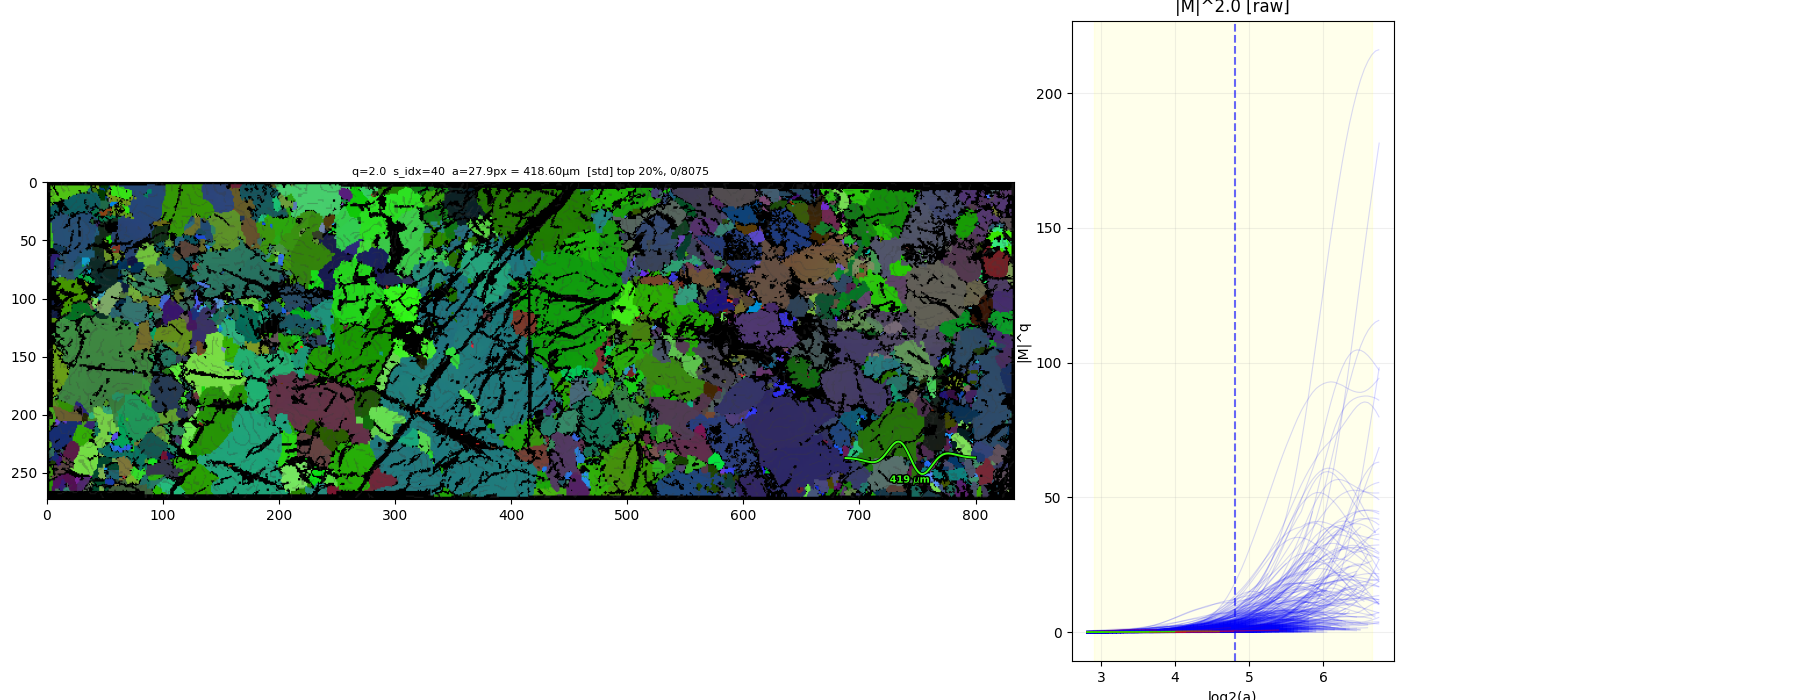

In [ ]:
# ===== WTMMM viewer: interactive map + profile + D(h) =====
# Purely-thermodynamic classifier: plateau-integrated canonical weight at q+.
# No single-scale percentile; no chain-slope h_j estimates (Meyer critique).
# Chhabra-Jensen (1989) + Muzy-Bacry-Arneodo (1994) on the WTMM chain set.
%matplotlib widget
from ipywidgets import interactive, IntRangeSlider, IntSlider, FloatSlider, \
    Dropdown, Checkbox, Layout
from IPython.display import display as _display_scalebar
from matplotlib.collections import LineCollection

_w_cache = {}
log2_s_global = np.log2(np.array(scales))

def _plateau_scale_indices(plateau_min_um, plateau_max_um):
    """Return the scale indices whose scales_um falls in the plateau."""
    scales_um_arr = np.array(scales) * px_um
    mask = (scales_um_arr >= plateau_min_um) & (scales_um_arr <= plateau_max_um)
    return np.where(mask)[0]

def chain_plateau_weights(q_plus, plateau_idx, use_chainmax=False, mode=None):
    """Plateau-integrated canonical weight W_j^plateau(q+) per chain.
    W_j^plateau(q+) = sum_{a in plateau} |W_j(a)|^{q+} / Z_{q+}(a).
    log-space, scatter-add to chain index via point_chain_idx_by_scale.
    Returns an array of shape (n_ch,).
    """
    mode = mode or VIEWER_ACTIVE_MODE
    vd = viewer_per_mode[mode]
    n_ch_m = vd['n_ch']
    w_chain = np.zeros(n_ch_m, dtype=np.float64)
    for si in plateau_idx:
        if si < 0 or si >= nps: continue
        mods = (vd['point_mod_by_scale_cmax'][si] if use_chainmax
                else vd['point_mod_by_scale_raw'][si])
        ci_arr = vd['point_chain_idx_by_scale'][si]
        if len(mods) == 0: continue
        log_m = np.log(np.maximum(mods, 1e-30))
        log_w = q_plus * log_m
        log_w -= log_w.max()
        w = np.exp(log_w)
        Z = w.sum()
        if Z <= 0: continue
        w = w / Z
        valid = ci_arr >= 0
        if valid.any():
            np.add.at(w_chain, ci_arr[valid], w[valid])
    return w_chain

def classify_chains_thermo(q_plus, top_pct, plateau_idx, use_chainmax=False, mode=None):
    """Thermodynamic classifier: top N% of plateau-integrated canonical weight at q+.
    Returns (is_phase_mask, info_string).
    """
    mode = mode or VIEWER_ACTIVE_MODE
    vd = viewer_per_mode[mode]
    n_ch_m = vd['n_ch']
    if abs(q_plus) < 1e-3:
        return np.ones(n_ch_m, dtype=bool), \
               f'q+~0 degenerate -> all {n_ch_m} chains grouped'
    if top_pct >= 99.999:
        return np.ones(n_ch_m, dtype=bool), f'top 100%: all {n_ch_m}'
    if top_pct <= 0.0:
        return np.zeros(n_ch_m, dtype=bool), 'top 0%: empty phase set'
    if len(plateau_idx) == 0:
        return np.zeros(n_ch_m, dtype=bool), 'empty plateau'
    w_chain = chain_plateau_weights(q_plus, plateau_idx, use_chainmax, mode)
    w_nz = w_chain[w_chain > 0]
    if len(w_nz) == 0:
        return np.zeros(n_ch_m, dtype=bool), 'no chain carries weight'
    cutoff = np.percentile(w_nz, 100.0 - top_pct)
    is_phase = w_chain >= cutoff
    return is_phase, f'top {top_pct:.0f}% @ q+={q_plus:.2f}, {is_phase.sum()}/{n_ch_m}'

def compute_partition_subset(chain_mask, display_chainmax, mode=None):
    """Partition sums restricted to chain subset.
    Returns (STq, STqlogT) of shape (n_q_pf, nps).
    """
    mode = mode or VIEWER_ACTIVE_MODE
    vd = viewer_per_mode[mode]
    STq = np.zeros((n_q_pf, nps))
    STqlogT = np.zeros((n_q_pf, nps))
    for si in range(nps):
        ci_arr = vd['point_chain_idx_by_scale'][si]
        if not len(ci_arr): continue
        valid_ci = ci_arr >= 0
        subset = np.zeros(len(ci_arr), dtype=bool)
        subset[valid_ci] = chain_mask[ci_arr[valid_ci]]
        if not subset.any(): continue
        if display_chainmax:
            m = vd['point_mod_by_scale_cmax'][si]
            log_m = np.log(np.maximum(m, 1e-30))
            mq = np.power(m[:, None], q_pf_global[None, :])
            mq[:, q0_mask_global] = 1.0
            logm_mq = log_m[:, None] * mq
        else:
            mq = vd['point_mq_by_scale'][si]
            logm_mq = vd['point_logm_mq_by_scale'][si]
        STq[:, si] = mq[subset].sum(0)
        STqlogT[:, si] = logm_mq[subset].sum(0)
    return STq, STqlogT

def _build_hd_from_partition(STq, STqlogT):
    """tau / h / D from partition-function sums.  Chhabra-Jensen canonical form."""
    log2_c = np.log(2.0)
    tau = np.full((n_q_pf, nps), np.nan)
    h_  = np.full((n_q_pf, nps), np.nan)
    D_  = np.full((n_q_pf, nps), np.nan)
    vZ = STq > 0
    tau[vZ] = np.log(STq[vZ]) / log2_c
    h_[vZ]  = STqlogT[vZ] / (log2_c * STq[vZ])
    for iq, qq in enumerate(q_pf_global):
        good = STq[iq] > 0
        if np.any(good):
            D_[iq, good] = (qq * STqlogT[iq, good]
                            - STq[iq, good] * np.log(STq[iq, good])) \
                           / (STq[iq, good] * log2_c)
    return {'tau_qa': tau, 'h_qa': h_, 'D_qa': D_,
            'q_list': q_pf_global, 'scales': np.array(scales),
            'log2_scales': np.log2(np.array(scales))}

# get_w: per-scale Boltzmann weights retained ONLY for map-point sizing / profile coloring.
# Not used for classification.
def get_w(si, q_val, use_chainmax=False, mode=None):
    mode = mode or VIEWER_ACTIVE_MODE
    key = (mode, int(si), float(q_val), bool(use_chainmax))
    if key in _w_cache: return _w_cache[key]
    vd = viewer_per_mode[mode]
    lm = vd['wt_logmod_by_scale'][si]
    if len(lm) == 0: _w_cache[key] = np.array([]); return _w_cache[key]
    if use_chainmax:
        lm = lm.copy()
        wx = vd['wt_x_by_scale'][si]; wy = vd['wt_y_by_scale'][si]
        cmx = vd['chainmax']
        for j in range(len(lm)):
            xy = (int(wx[j]), int(wy[j]))
            m_sup = cmx[si].get(xy, None) if si < len(cmx) else None
            if m_sup is not None and m_sup > 0: lm[j] = np.log(max(m_sup, 1e-30))
    log_w = q_val * lm; log_w -= log_w.max(); w = np.exp(log_w); Z = w.sum()
    out = w / Z if Z > 0 else w
    _w_cache[key] = out
    return out

_cm = {'red':(255,60,60),'yellow':(255,255,0),'cyan':(0,255,255),
       'lime':(0,255,0),'magenta':(255,0,255),'orange':(255,165,0),
       'white':(255,255,255),'gray':(120,120,120),'dark gray':(60,60,60),
       'blue':(50,100,255),'green':(50,200,50)}

def compute_spectra_fast(is_phase_chain, display_chainmax, mode=None):
    """Phase / multifractal-bulk / total spectra via partition-function subsetting."""
    mode = mode or VIEWER_ACTIVE_MODE
    vd = viewer_per_mode[mode]
    STq_p, SL_p = compute_partition_subset(is_phase_chain, display_chainmax, mode)
    STq_m, SL_m = compute_partition_subset(~is_phase_chain, display_chainmax, mode)
    hd_all = vd['hd_all_cmax_pre'] if display_chainmax else vd['hd_all_raw_pre']
    return hd_all, _build_hd_from_partition(STq_p, SL_p), _build_hd_from_partition(STq_m, SL_m)

# Module-level widgets (shared with the 3-group cell after cell 33)
q_plus_w = FloatSlider(value=2.0, min=0.1, max=10.0, step=0.25, description='q+:',
                       layout=Layout(width='70%'), continuous_update=False)
top_pct_w = FloatSlider(value=20.0, min=0.0, max=100.0, step=1.0,
                        description='Top %:', layout=Layout(width='60%'),
                        continuous_update=False)

def _sync_topct_enable(change):
    top_pct_w.disabled = abs(change['new']) < 1e-3
q_plus_w.observe(_sync_topct_enable, names='value')
_sync_topct_enable({'new': q_plus_w.value})

_fig_v = plt.figure(figsize=(18, 7))
_gs_v = _fig_v.add_gridspec(1, 3, width_ratios=[3, 1, 1])
_ax_map  = _fig_v.add_subplot(_gs_v[0, 0])
_ax_prof = _fig_v.add_subplot(_gs_v[0, 1])
_ax_dh   = _fig_v.add_subplot(_gs_v[0, 2])
_fig_v.tight_layout()

def draw_map(svd_mode, scale_idx, fit_range, q_plus, top_pct, min_vc, min_hchain,
             classify_chainmax, display_chainmax, show_mode, bg_type, dom_color,
             dom_alpha, non_color_name, non_alpha, dom_width, non_width, point_size,
             show_spectra):
    if svd_mode != VIEWER_ACTIVE_MODE:
        activate_viewer_mode(svd_mode)
    vd = viewer_per_mode[svd_mode]
    ext_images              = vd['ext_images']
    chain_segments_by_scale = vd['chain_segments_by_scale']
    wt_x_by_scale           = vd['wt_x_by_scale']
    wt_y_by_scale           = vd['wt_y_by_scale']
    wt_logmod_by_scale      = vd['wt_logmod_by_scale']
    wt_arg_by_scale         = vd['wt_arg_by_scale']
    maxima_coords_cache     = vd['maxima_coords_cache']
    wtmmm_to_chain_by_scale = vd['wtmmm_to_chain_by_scale']
    running_max_matrix      = vd['running_max_matrix']
    skel_chains             = vd['skel_chains']
    chain_n                 = vd['chain_n']
    n_ch                    = vd['n_ch']

    # Classifier plateau from pf_state (Regime I of interactive PF fit).
    if 'pf_state' in globals() and svd_mode in pf_state:
        _ps = pf_state[svd_mode]
        plateau_min = _ps.get('scale_min', float(np.array(scales)[0] * px_um))
        plateau_max = _ps.get('scale_max', float(np.array(scales)[-1] * px_um))
    else:
        plateau_min = float(np.array(scales)[0] * px_um)
        plateau_max = float(np.array(scales)[-1] * px_um)
    plateau_idx = _plateau_scale_indices(plateau_min, plateau_max)
    is_phase_chain, thresh_info = classify_chains_thermo(
        q_plus, top_pct, plateau_idx, classify_chainmax, mode=svd_mode)

    wt2ch = wtmmm_to_chain_by_scale[scale_idx]
    is_phase_wt = np.zeros(len(wt2ch), dtype=bool)
    valid_wt = wt2ch >= 0
    is_phase_wt[valid_wt] = is_phase_chain[wt2ch[valid_wt]]
    w_all = get_w(scale_idx, q_plus, classify_chainmax, mode=svd_mode)

    dc = _cm.get(dom_color, (255, 60, 60))
    nc = _cm.get(non_color_name, (60, 60, 60))
    da = int(round(dom_alpha * 255)); na = int(round(non_alpha * 255))
    dw = 0 if dom_width <= 0 else max(1, int(np.ceil(dom_width)))
    nw = 0 if non_width <= 0 else max(1, int(np.ceil(non_width)))

    bg = bg_dict.get(bg_type, bg_dict['IPF-Z'])
    base = Image.fromarray(bg.copy()).convert('RGBA')
    overlay = Image.new('RGBA', base.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay, 'RGBA')

    if show_mode in ('Chains + WTMMM', 'Chains only', 'Chains + maxima lines'):
        for is_d_pass in [False, True]:
            for coords, wt_idx, n_pts in chain_segments_by_scale[scale_idx]:
                if n_pts < min_hchain or len(coords) < 2: continue
                seg_dom = (wt_idx is not None and wt_idx < len(is_phase_wt) and is_phase_wt[wt_idx])
                if seg_dom != is_d_pass: continue
                color = dc if seg_dom else nc
                alpha = da if seg_dom else na
                width = dw if seg_dom else nw
                if alpha > 0 and width > 0:
                    draw.line([(int(x), int(y)) for x, y in coords],
                              fill=(*color, alpha), width=width)
    if show_mode in ('Chains + WTMMM', 'WTMMM only', 'Arrows (argument)'):
        wx = wt_x_by_scale[scale_idx]; wy = wt_y_by_scale[scale_idx]
        w_max_local = w_all.max() + 1e-30 if len(w_all) > 0 else 1.0
        arg_arr = wt_arg_by_scale[scale_idx] if show_mode == 'Arrows (argument)' else None
        mod_arr = np.exp(wt_logmod_by_scale[scale_idx]) if len(wt_logmod_by_scale[scale_idx]) > 0 else np.array([])
        mod_max_s = mod_arr.max() + 1e-30 if len(mod_arr) > 0 else 1.0
        for is_d_pass in [False, True]:
            for j in range(len(wx)):
                if j >= len(w_all) or w_all[j] <= 0: continue
                is_d = j < len(is_phase_wt) and is_phase_wt[j]
                if is_d != is_d_pass: continue
                color_pt = dc if is_d else nc
                alpha_pt = da if is_d else na
                width_pt = dw if is_d else nw
                if alpha_pt <= 0: continue
                px, py = int(wx[j]), int(wy[j])
                if arg_arr is not None and j < len(arg_arr):
                    arg_val = float(arg_arr[j])
                    mod_n = mod_arr[j] / mod_max_s if j < len(mod_arr) else 0
                    al = mod_n * point_size
                    dx_a, dy_a = np.cos(arg_val) * al, np.sin(arg_val) * al
                    draw.line([(px, py), (int(px + dx_a), int(py + dy_a))],
                              fill=(*color_pt, alpha_pt), width=max(1, width_pt))
                    draw.ellipse([px - 2, py - 2, px + 2, py + 2],
                                 fill=(*color_pt, alpha_pt))
                else:
                    w_n = w_all[j] / w_max_local
                    r = max(1, int(point_size / 10 * (0.3 + 0.7 * w_n)))
                    draw.ellipse([px - r, py - r, px + r, py + r],
                                 fill=(*color_pt, alpha_pt))
    if show_mode in ('Maxima lines', 'Chains + maxima lines'):
        for is_d_pass in [False, True]:
            for ci in range(n_ch):
                if chain_n[ci] < min_vc: continue
                coords = maxima_coords_cache[ci]
                if coords is None: continue
                is_d = is_phase_chain[ci]
                if is_d != is_d_pass: continue
                color = dc if is_d else nc
                alpha = da if is_d else na
                width = dw if is_d else nw
                if alpha > 0 and width > 0:
                    draw.line(coords, fill=(*color, alpha), width=width)
    rendered = np.array(Image.alpha_composite(base, overlay).convert('RGB'))

    _ax_map.cla(); _ax_prof.cla(); _ax_dh.cla()
    _ax_dh.set_visible(show_spectra)
    _ax_map.imshow(rendered, origin='upper', extent=[0, nxp, nyp, 0], aspect='equal')
    add_wavelet_scalebar(_ax_map, scale=float(scales[scale_idx]),
                         px_to_unit=px_um, unit_str=r'$\mu$m',
                         wavelet=WAVELET)
    method = 'cmax' if classify_chainmax else 'std'
    deg_note = ' [q+~=0 deg.]' if abs(q_plus) < 1e-3 else ''
    _ax_map.set_title(f'[{svd_mode}]  q+={q_plus:.2f}  s_idx={scale_idx}  '
                      f'a={scales[scale_idx]:.1f}px = {scales[scale_idx]*px_um:.2f}um  '
                      f'[{method}]{deg_note}  {thresh_info}', fontsize=8)

    fit_lo, fit_hi = fit_range
    cmap_prof = plt.cm.brg
    w_ci = get_w(scale_idx, q_plus, classify_chainmax, mode=svd_mode)
    w_color = np.zeros(n_ch, dtype=np.float64)
    for ci in range(min(n_ch, len(w_ci))):
        if chain_n[ci] >= min_vc: w_color[ci] = w_ci[ci]
    w_max = w_color.max() if w_color.max() > 0 else 1.0
    _active_cis = sorted([ci for ci in range(n_ch) if chain_n[ci] >= min_vc],
                         key=lambda c: w_color[c])
    lc_segs = []; lc_colors = []
    for ci in _active_cis:
        sc = skel_chains[ci]; n_sc_local = sc['n']
        if n_sc_local < 2: continue
        mvals = running_max_matrix[ci, :n_sc_local] if display_chainmax else sc['mod'][:n_sc_local]
        with np.errstate(invalid='ignore'):
            yvals = np.power(mvals, q_plus) if q_plus != 0 else mvals
        pts = np.column_stack([sc['log2_s'], yvals])
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        lc_segs.append(segs)
        wn = w_color[ci] / w_max
        c = cmap_prof(wn)
        lc_colors.extend([(*c[:3], 0.15 + 0.85 * wn)] * len(segs))
    if lc_segs:
        lc = LineCollection(np.concatenate(lc_segs), colors=lc_colors, linewidths=0.8)
        _ax_prof.add_collection(lc); _ax_prof.autoscale()
    _ax_prof.axvline(log2_s_global[scale_idx], color='blue', ls='--', alpha=0.6, lw=1.5)
    _ax_prof.axvspan(log2_s_global[fit_lo], log2_s_global[fit_hi],
                     alpha=0.08, color='yellow')
    _ax_prof.set(xlabel='log2(a)',
                 ylabel=('|M|^q+' if q_plus != 0 else '|M|'),
                 title=f'|M|^{q_plus:.2f} [{"cmax" if display_chainmax else "raw"}]')
    _ax_prof.grid(True, alpha=0.2)

    if show_spectra:
        fit_lo_s, fit_hi_s = scales[fit_lo], scales[fit_hi]
        sr = (fit_lo_s, fit_hi_s)
        dom_plot_c = tuple(np.array(dc) / 255.0)
        non_plot_c = tuple(np.array(nc) / 255.0)
        hd_all, hd_p, hd_m = compute_spectra_fast(is_phase_chain, display_chainmax, mode=svd_mode)
        for hd_cur, color, label in [(hd_all, 'black', 'Total'),
                                      (hd_p, dom_plot_c, 'Phase transition'),
                                      (hd_m, non_plot_c, 'Multifractal bulk')]:
            try:
                sp = extract_hq_Dq_from_plateaus(hd_cur, scale_range=sr)
                vd_ = np.isfinite(sp['D']) & np.isfinite(sp['h'])
                if vd_.any():
                    _fie = globals().get('FRACINT_ALPHA', 0.0)
                    h_corr = sp['h'][vd_] - _fie
                    _ax_dh.plot(h_corr, sp['D'][vd_], '.-', color=color, lw=2, label=label)
            except Exception:
                pass
        _ax_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        _ax_dh.set(xlabel='h', ylabel='D(h)',
                   title=f'D(h) [{"cmax" if display_chainmax else "raw"}]')
        _ax_dh.legend(fontsize=7); _ax_dh.grid(True, alpha=0.3)

    _fig_v.canvas.draw_idle()

_scalebar_interactive = interactive(
    draw_map,
    svd_mode=Dropdown(options=VIEWER_MODES, value=VIEWER_ACTIVE_MODE,
                      description='SVD mode:'),
    scale_idx=IntSlider(value=nps // 2, min=0, max=nps - 1, description='Scale:',
                        layout=Layout(width='70%'), continuous_update=False),
    fit_range=IntRangeSlider(value=[2, nps - 3], min=0, max=nps - 1,
                             description='Fit range:', layout=Layout(width='70%'),
                             continuous_update=False),
    q_plus=q_plus_w,
    top_pct=top_pct_w,
    min_vc=IntSlider(value=3, min=1, max=30, step=1, description='Min vc:',
                     layout=Layout(width='50%'), continuous_update=False),
    min_hchain=IntSlider(value=5, min=1, max=200, step=1, description='Min h-chain:',
                         layout=Layout(width='60%'), continuous_update=False),
    classify_chainmax=Checkbox(value=False, description='Classify chainmax'),
    display_chainmax=Checkbox(value=False, description='Display chainmax'),
    show_mode=Dropdown(options=['Chains + WTMMM', 'WTMMM only', 'Arrows (argument)',
                                'Maxima lines', 'Chains + maxima lines', 'Chains only'],
                       value='Chains + WTMMM', description='Show:'),
    bg_type=Dropdown(options=list(bg_dict.keys()), value='IPF-Z', description='Background:'),
    dom_color=Dropdown(options=['red', 'yellow', 'cyan', 'lime', 'magenta', 'orange',
                                 'white', 'blue', 'green'], value='red',
                       description='Phase color:'),
    dom_alpha=FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05, description='Phase alpha:',
                          layout=Layout(width='50%'), continuous_update=False),
    non_color_name=Dropdown(options=['red', 'yellow', 'cyan', 'lime', 'magenta',
                                      'orange', 'white', 'blue', 'green', 'gray',
                                      'dark gray'], value='dark gray',
                            description='Bulk color:'),
    non_alpha=FloatSlider(value=0.3, min=0.0, max=1.0, step=0.05, description='Bulk alpha:',
                          layout=Layout(width='50%'), continuous_update=False),
    dom_width=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.5, description='Phase width:',
                          layout=Layout(width='50%'), continuous_update=False),
    non_width=FloatSlider(value=1.0, min=0.0, max=3.0, step=0.5, description='Bulk width:',
                          layout=Layout(width='50%'), continuous_update=False),
    point_size=FloatSlider(value=15.0, min=1.0, max=50.0, step=1.0,
                           description='Pt/arrow size:', layout=Layout(width='50%'),
                           continuous_update=False),
    show_spectra=Checkbox(value=False, description='Show D(h)'),
)
_display_scalebar(_scalebar_interactive)


## Log-log partition plots (static): $\tau(q,a)$, $h(q,a)$, $D(q,a)$

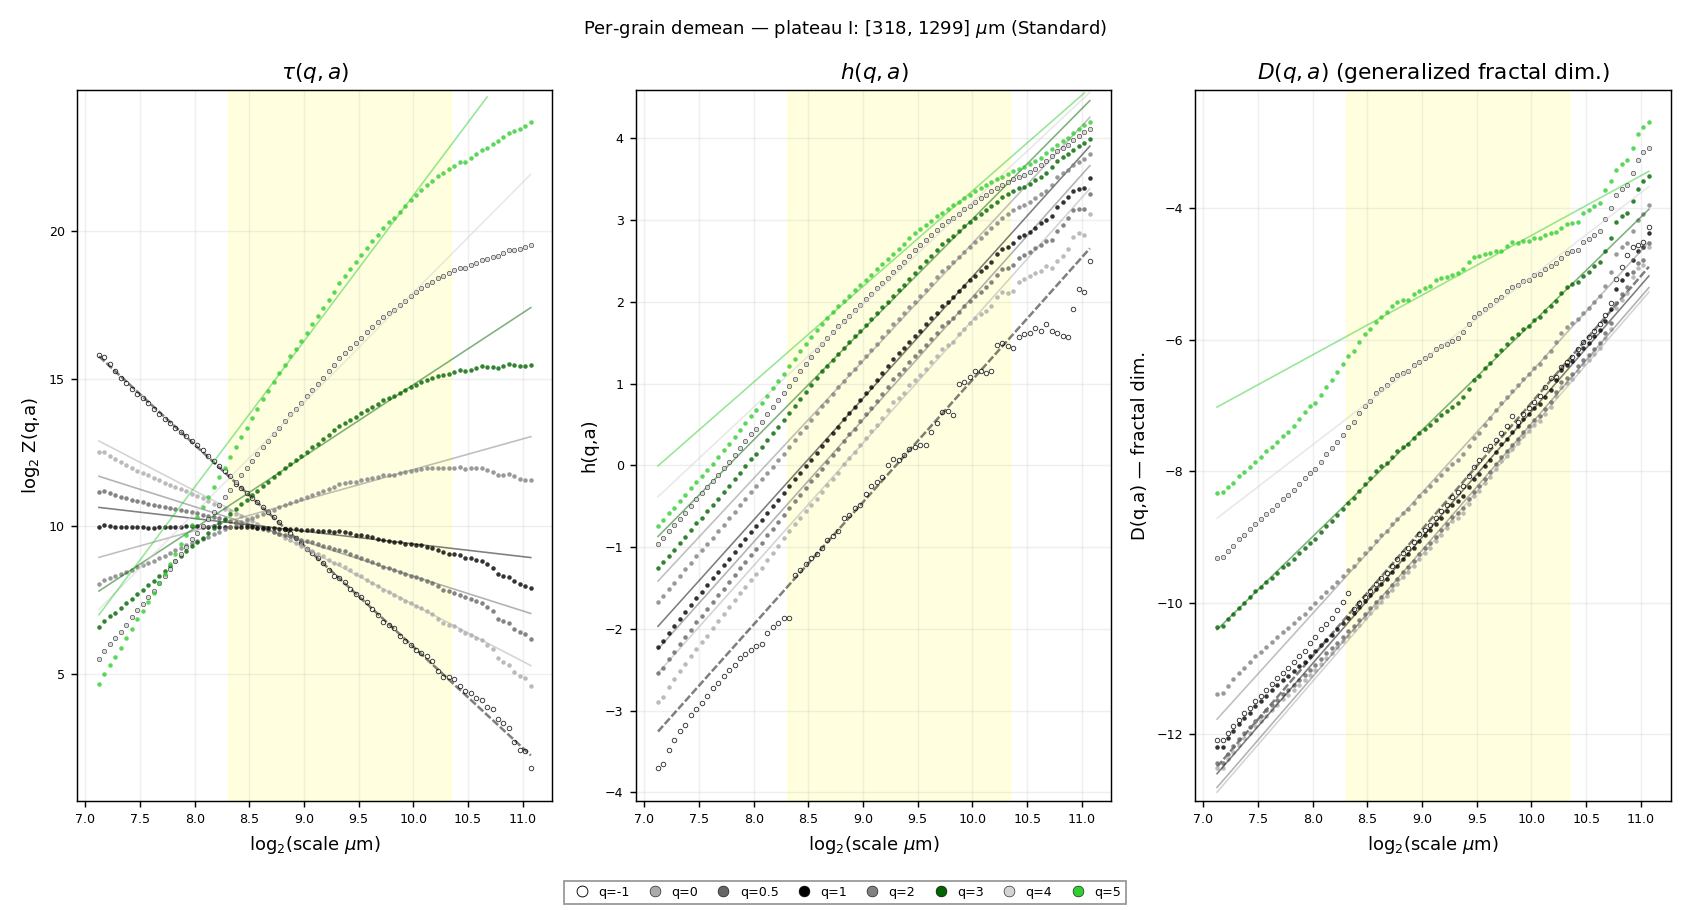

In [ ]:
# ===== Partition functions (log-log): tau(q,a), h(q,a), D(q,a) — publication format =====
# 1 x 3 square-tall panels. Integer q colored per convention, plateau band highlighted,
# linear fit overlaid. Non-interactive — set USE_CMAX_PF to switch.
# (Matches ebsd_ps_ultra.ipynb cell 17 layout.)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- parameters ----
USE_CMAX_PF     = False              # False = Standard, True = Chainmax (running-max form)
STATIC_SVD_MODE = SVD_MODE_VIEW      # which SVD mode to plot ('sigma_max'/'sigma_min'/'modL'/'modT')
# --------------------
# Plateau is inherited from `pf_state[STATIC_SVD_MODE]` (set interactively in the PF fit cell above).
# Override by editing that dict or setting USE_INHERITED_PLATEAU = False.
USE_INHERITED_PLATEAU = True

hd = (hd_cmax_per_mode[STATIC_SVD_MODE] if USE_CMAX_PF
      else hd_std_per_mode[STATIC_SVD_MODE])
log2_s = hd['log2_scales_um']
scales_um = hd['scales_um']

if (USE_INHERITED_PLATEAU and ('pf_state' in globals())
        and STATIC_SVD_MODE in pf_state):
    _ps = pf_state[STATIC_SVD_MODE]
    smin = _ps['scale_min']
    smax = _ps['scale_max']
    smin2 = _ps.get('scale_min_2')
    smax2 = _ps.get('scale_max_2')
    has_r2_static = smin2 is not None and smax2 is not None
else:
    lo_i = int(0.20 * len(log2_s))
    hi_i = max(lo_i + 3, int(0.80 * len(log2_s)))
    smin = scales_um[lo_i]; smax = scales_um[hi_i - 1]
    smin2 = smax2 = None
    has_r2_static = False

q_show = np.array([-1, 0, 0.5, 1, 2, 3, 4, 5])
_q_style = {
    -1:   {'color': 'white',     'mec': 'black', 'mew': 0.5},
    0:    {'color': '#aaaaaa',   'mec': 'none',  'mew': 0},
    0.5:  {'color': '#666666',   'mec': 'none',  'mew': 0},
    1:    {'color': 'black',     'mec': 'none',  'mew': 0},
    2:    {'color': 'gray',      'mec': 'none',  'mew': 0},
    3:    {'color': 'darkgreen', 'mec': 'none',  'mew': 0},
    4:    {'color': 'lightgray', 'mec': 'black', 'mew': 0.3},
    5:    {'color': 'limegreen', 'mec': 'none',  'mew': 0},
}

fig, axes = plt.subplots(1, 3, figsize=(13, 7), dpi=130)

panels = [
    ('tau_qa', r'log$_2$ Z(q,a)',               r'$\tau(q,a)$'),
    ('h_qa',   r'h(q,a)',                        r'$h(q,a)$'),
    ('D_qa',   r'D(q,a) — fractal dim.',         r'$D(q,a)$ (generalized fractal dim.)'),
]

for col, (key, ylabel, title) in enumerate(panels):
    ax = axes[col]
    # collect y range from data points
    all_y = []
    for qv in q_show:
        idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
        y = hd[key][idx]; v = np.isfinite(y)
        if v.any(): all_y.append(y[v])
    if all_y:
        all_y_cat = np.concatenate(all_y)
        ylo = float(np.min(all_y_cat)); yhi = float(np.max(all_y_cat))
        ypad = (yhi - ylo) * 0.05
        data_ylim = (ylo - ypad, yhi + ypad)
    else:
        data_ylim = None

    s1 = (scales_um >= smin) & (scales_um <= smax)
    for qv in q_show:
        sty = _q_style.get(qv, {'color': 'black', 'mec': 'none', 'mew': 0})
        color = sty['color']; fit_color = 'black' if color == 'white' else color
        idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
        y = hd[key][idx]; v = np.isfinite(y)
        if v.sum() < 2: continue
        ax.plot(log2_s[v], y[v], 'o', color=color, ms=2.5, alpha=0.8,
                mec=sty['mec'], mew=sty['mew'])
        yf = y[s1]; xf = log2_s[s1]; vf = np.isfinite(yf)
        if vf.sum() >= 2:
            sl, ic = np.polyfit(xf[vf], yf[vf], 1)
            x_line = log2_s[v]; y_line = sl * x_line + ic
            if data_ylim:
                clip = (y_line >= data_ylim[0]) & (y_line <= data_ylim[1])
                if clip.any():
                    ls_i = '-' if color != 'white' else (0, (3, 1))
                    lw_i = 0.9 if color != 'white' else 1.4
                    ax.plot(x_line[clip], y_line[clip], ls=ls_i, color=fit_color, lw=lw_i, alpha=0.5)

    ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.12, color='yellow', zorder=0)
    if has_r2_static:
        ax.axvspan(np.log2(smin2), np.log2(smax2), alpha=0.12, color='cyan', zorder=0)
    if data_ylim: ax.set_ylim(data_ylim)
    ax.set(xlabel=r'log$_2$(scale $\mu$m)', ylabel=ylabel, title=title)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

suptitle = f'[{STATIC_SVD_MODE}] Per-grain demean — plateau I: [{smin:.0f}, {smax:.0f}]'
if has_r2_static: suptitle += f'   II: [{smin2:.0f}, {smax2:.0f}]'
suptitle += r' $\mu$m' + (' (Chainmax)' if USE_CMAX_PF else ' (Standard)')
fig.suptitle(suptitle, fontsize=10)

handles = []
for qv in q_show:
    sty = _q_style.get(qv, {'color': 'black', 'mec': 'none', 'mew': 0})
    handles.append(Line2D([0], [0], marker='o', color='none',
                          markerfacecolor=sty['color'],
                          markeredgecolor=sty['mec'] if sty['mec'] != 'none' else 'black',
                          markeredgewidth=max(sty['mew'], 0.3), ms=6,
                          label=f'q={qv:g}'))
fig.legend(handles=handles, loc='lower center', ncol=len(q_show),
           fontsize=7, frameon=True, fancybox=False, edgecolor='gray',
           bbox_to_anchor=(0.5, 0.0), columnspacing=1.0, handletextpad=0.3)
fig.tight_layout(); fig.subplots_adjust(bottom=0.12)
plt.show()


## Publication spectra: $\tau(q)$, $D(h)$, $h(q)$, $C(q)$

Circles = Regime I; squares = Regime II (if set in interactive PF fitter above).
Slide q_crit to show tangent line on D(h) at the chosen q.


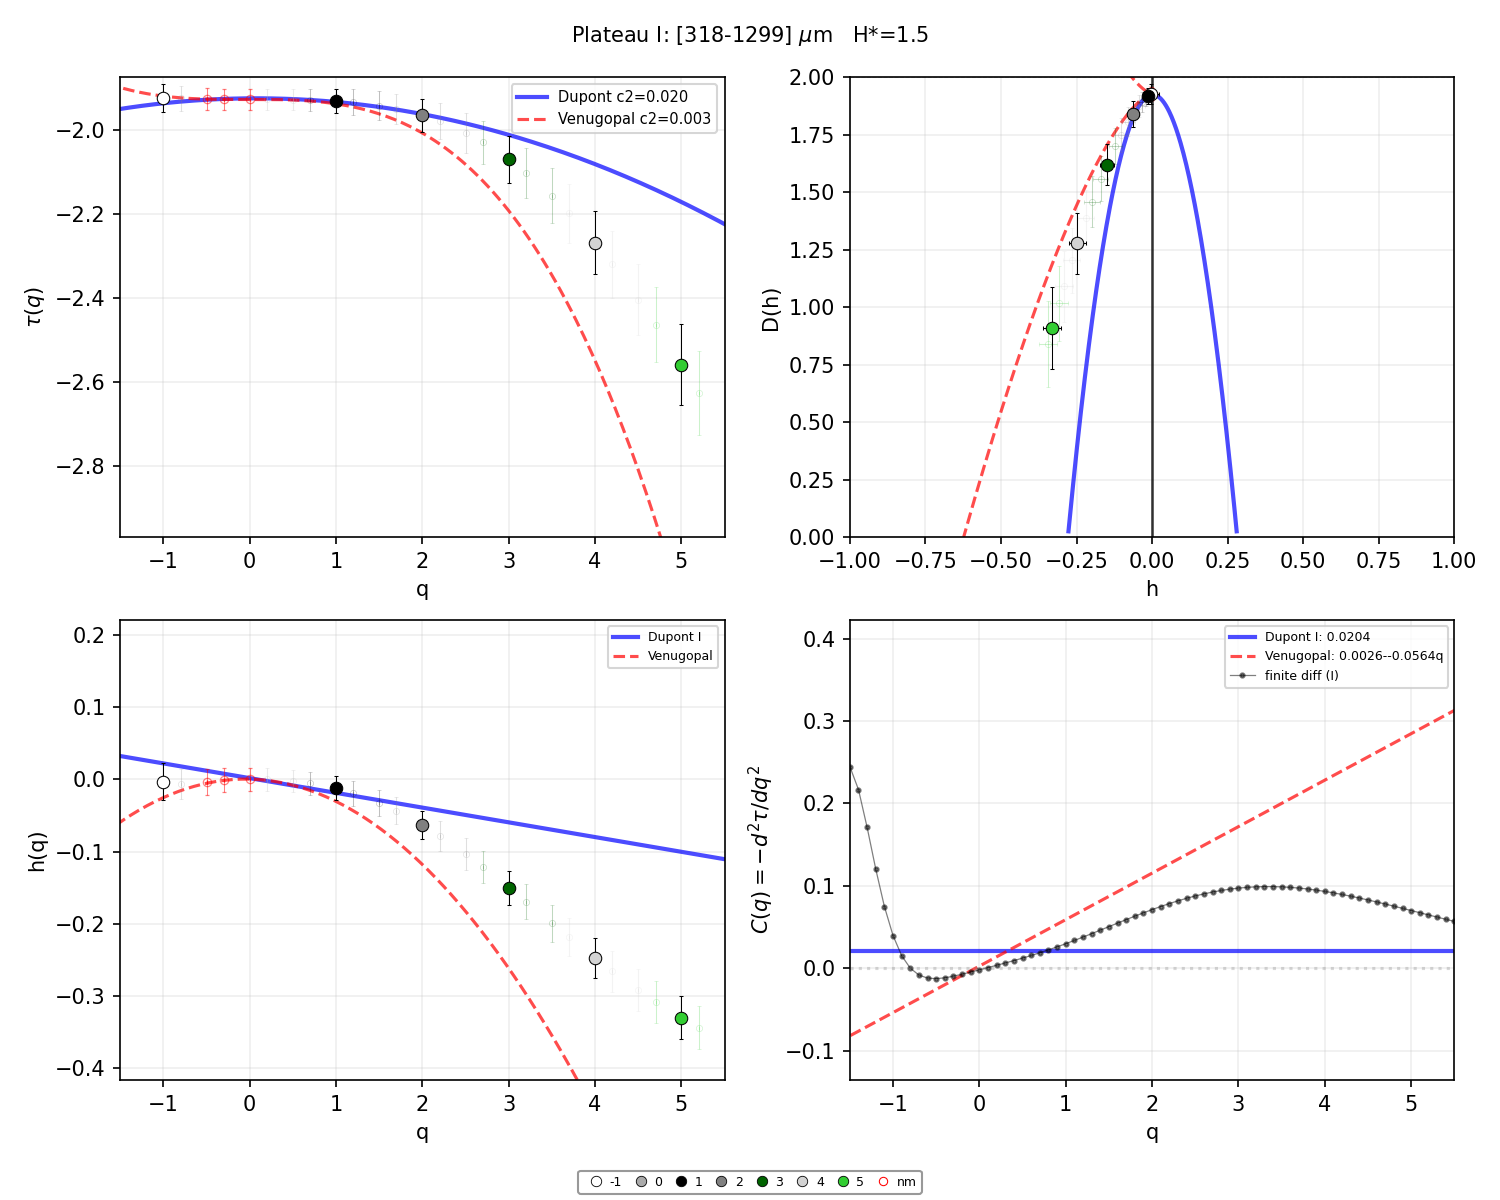

In [ ]:
# ===== Publication spectra: tau(q), D(h), h(q), C(q) — 2x2 =====
# Matches ebsd_ps_ultra.ipynb cell 18 (single-sample version).
# Interactive: q_crit slider (draws tangent line on D(h)),
# Standard/Chainmax toggle, Regime II squares overlay.
# Plateau and q-range are sourced from pf_state (interactive PF fitter above).

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.lines import Line2D
# Using local fit_hq_Dq_weighted (defined in partition cell) for sample-variance errors

_pub_modes = [m for m in SVD_MODES_RUN if m in svd_wtmm
              and m in hd_std_per_mode and m in cum_per_mode]
pub_mode_dd = widgets.Dropdown(options=_pub_modes, value=SVD_MODE_VIEW,
    description='SVD mode:')
pub_cmax_tog = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
    value='Standard', description='PF:')
pub_qcrit = widgets.FloatSlider(value=0.0, min=0.0, max=6.0, step=0.1,
    description='q_crit:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='350px'))

_int_colors = {-1: 'white', 0: '#aaaaaa', 1: 'black', 2: 'gray',
               3: 'darkgreen', 4: 'lightgray', 5: 'limegreen'}
q_all = np.arange(-1, 5.26, 0.25)

def _pub_style(qi, is_nm=False):
    is_int = abs(qi - round(qi)) < 0.01 and round(qi) in _int_colors
    if is_nm:  return dict(fc='none', ec='red', ew=0.6, alpha=0.5, ms=4)
    if is_int: return dict(fc=_int_colors[round(qi)], ec='black', ew=0.5, alpha=1.0, ms=6)
    nearest = min(_int_colors, key=lambda k: abs(k - qi))
    ec = _int_colors[nearest]
    if ec == 'white': ec = 'gray'
    return dict(fc='none', ec=ec, ew=0.3, alpha=0.25, ms=3)

def _plot_pts(ax, xv, yv, yerr, q_arr, vmask, nm_map=None, marker='o', xerr=None):
    for qi in q_all:
        idx = int(np.argmin(np.abs(q_arr - qi)))
        if abs(q_arr[idx] - qi) > 0.13 or not vmask[idx]: continue
        is_nm = nm_map.get(idx, False) if nm_map else False
        s = _pub_style(qi, is_nm)
        ye = yerr[idx] if np.isfinite(yerr[idx]) else 0
        xe = (xerr[idx] if (xerr is not None and np.isfinite(xerr[idx])) else 0)
        ax.errorbar(xv[idx], yv[idx], xerr=xe, yerr=ye, fmt=marker, ms=s['ms'],
                    mfc=s['fc'], mec=s['ec'], mew=s['ew'],
                    ecolor=s['ec'] if not is_nm else 'red',
                    elinewidth=0.5, capsize=1, alpha=s['alpha'],
                    zorder=6 if s['alpha'] > 0.5 else 3)

def _plot_r2(ax, xv, yv, yerr, q_arr, vmask, xerr=None):
    for qi in q_all:
        idx = int(np.argmin(np.abs(q_arr - qi)))
        if abs(q_arr[idx] - qi) > 0.13 or not vmask[idx]: continue
        is_int = abs(qi - round(qi)) < 0.01 and round(qi) in _int_colors
        if is_int:
            fc = _int_colors.get(round(qi), 'gray')
            if fc == 'white': fc = 'none'
            ms = 5; alp = 0.7; ec = 'black'
        else:
            fc = 'none'; ms = 3; alp = 0.2; ec = 'gray'
        ye = yerr[idx] if np.isfinite(yerr[idx]) else 0
        xe = (xerr[idx] if (xerr is not None and np.isfinite(xerr[idx])) else 0)
        ax.errorbar(xv[idx], yv[idx], xerr=xe, yerr=ye, fmt='s', ms=ms,
                    mfc=fc, mec=ec, mew=0.5, ecolor=ec, elinewidth=0.4,
                    capsize=1, alpha=alp, zorder=3)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=150)

def pub_draw(*_):
    mode = pub_mode_dd.value
    use_cmax = 'Chainmax' in pub_cmax_tog.value
    Hstar = FRACINT_ALPHA
    hd = hd_cmax_per_mode[mode] if use_cmax else hd_std_per_mode[mode]
    _ps = pf_state[mode]
    smin, smax = _ps['scale_min'], _ps['scale_max']
    smin2, smax2 = _ps.get('scale_min_2'), _ps.get('scale_max_2')
    # Regime II active only if checkbox is ticked AND plateau is set.
    # This makes the publication cell track the interactive cell's checkbox.
    has_r2 = (pf_regime2_cb.value if 'pf_regime2_cb' in globals() else True) \
             and (smin2 is not None) and (smax2 is not None)
    qmn, qmx = _ps.get('qmin', -0.5), _ps.get('qmax', 5.0)

    res = fit_hq_Dq_weighted(hd, scale_range=(smin / px_um, smax / px_um))
    q   = res['q_list']
    tau = res['tau'] - Hstar * q
    h   = res['h']  - Hstar
    D   = res['D']
    te  = res['tau_err']; he = res['h_err']; de = res['D_err']
    v   = np.isfinite(tau) & np.isfinite(h) & np.isfinite(D)
    qv = q[v]; hv = h[v]; dhdq = np.gradient(hv, qv)
    nm = {iv: dhdq[k] > 0 for k, iv in enumerate(np.where(v)[0])}

    q2 = tau2 = h2 = D2 = te2 = he2 = de2 = None; v2 = None
    if has_r2:
        r2 = fit_hq_Dq_weighted(hd, scale_range=(smin2 / px_um, smax2 / px_um))
        q2 = r2['q_list']; tau2 = r2['tau'] - Hstar * q2
        h2  = r2['h'] - Hstar; D2 = r2['D']
        te2 = r2['tau_err']; he2 = r2['h_err']; de2 = r2['D_err']
        v2  = np.isfinite(tau2) & np.isfinite(h2) & np.isfinite(D2)

    # Dupont quadratic fit in [qmn, qmx]
    fm = v & (q >= qmn) & (q <= qmx)
    c0p = c1p = c2p = np.nan
    if fm.sum() >= 4:
        wf = np.ones(fm.sum()); tef = te[fm]; gef = np.isfinite(tef) & (tef > 0)
        if gef.any(): wf[gef] = 1.0 / tef[gef]
        pp = np.polyfit(q[fm], tau[fm], 2, w=wf)
        c0p = -pp[2]; c1p = pp[1]; c2p = -2 * pp[0]

    # Dupont quadratic fit Regime II
    c0p2 = c1p2 = c2p2 = np.nan
    if has_r2 and v2 is not None:
        fm2 = v2 & (q2 >= qmn) & (q2 <= qmx)
        if fm2.sum() >= 4:
            w2 = np.ones(fm2.sum()); te22 = te2[fm2]
            ge2 = np.isfinite(te22) & (te22 > 0)
            if ge2.any(): w2[ge2] = 1.0 / te22[ge2]
            pp2 = np.polyfit(q2[fm2], tau2[fm2], 2, w=w2)
            c0p2 = -pp2[2]; c1p2 = pp2[1]; c2p2 = -2 * pp2[0]

    # Venugopal cumulants from the same plateau (Regime I)
    _Cset = cum_per_mode[mode]
    C = _Cset['C_cmax'] if use_cmax else _Cset['C_std']
    fmc = (scales_um >= smin) & (scales_um <= smax)
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c_ven = {}
    for n in range(4):
        y = C[n]; vv = np.isfinite(y) & fmc
        if vv.sum() < 3: c_ven[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[vv], y[vv], 1)
        c_ven[n] = sign_map[n] * sl
    c0v = c_ven[0]
    c1v = (c_ven[1] - Hstar) if np.isfinite(c_ven.get(1, np.nan)) else np.nan
    c2v = abs(c_ven[2]) if np.isfinite(c_ven.get(2, np.nan)) else np.nan
    c3v = c_ven.get(3, 0.0) if np.isfinite(c_ven.get(3, np.nan)) else 0.0

    qd = np.linspace(-2, 7, 300)
    for ax in axes.flat: ax.cla()

    # === tau(q) ===
    ax = axes[0, 0]
    _plot_pts(ax, q, tau, te, q, v, nm)
    if has_r2 and v2 is not None: _plot_r2(ax, q2, tau2, te2, q2, v2)
    if np.isfinite(c0p):
        ax.plot(qd, -c0p + c1p * qd - c2p * qd ** 2 / 2, 'b-', lw=2, alpha=0.7,
                label=f'Dupont c2={c2p:.3f}')
    # Venugopal log-normal cascade: tau = -c0 + c1 q - c2 q^2/2 (c3 dropped)
    if np.isfinite(c0v):
        ax.plot(qd, -c0v + c1v * qd - c2v * qd ** 2 / 2,
                'r--', lw=1.5, alpha=0.7,
                label=f'Venugopal (log-normal) c2={c2v:.3f}')
    _q2 = q2[v2] if (has_r2 and v2 is not None) else None
    _t2 = tau2[v2] if (has_r2 and v2 is not None) else None
    _xr = _pf_range(q[v], _q2)
    _yr = _pf_range(tau[v], _t2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.set(xlabel='q', ylabel=r'$\tau(q)$')
    ax.grid(True, alpha=0.2); ax.legend(fontsize=7)

    # === D(h) ===
    ax = axes[0, 1]
    _plot_pts(ax, h, D, de, q, v, nm, xerr=he)
    if has_r2 and v2 is not None: _plot_r2(ax, h2, D2, de2, q2, v2, xerr=he2)
    if np.isfinite(c0p) and c2p > 1e-6:
        ds = np.sqrt(2 * c0p * c2p) if c0p * c2p > 0 else 1.0
        hh = np.linspace(c1p - ds, c1p + ds, 300)
        dd = c0p - (hh - c1p) ** 2 / (2 * c2p)
        ax.plot(hh, np.where(dd >= 0, dd, np.nan), 'b-', lw=2, alpha=0.7)
    if np.isfinite(c0p2) and c2p2 > 1e-6:
        ds2 = np.sqrt(2 * c0p2 * c2p2) if c0p2 * c2p2 > 0 else 1.0
        hh2x = np.linspace(c1p2 - ds2, c1p2 + ds2, 300)
        dd2 = c0p2 - (hh2x - c1p2) ** 2 / (2 * c2p2)
        ax.plot(hh2x, np.where(dd2 >= 0, dd2, np.nan), 'c-', lw=2, alpha=0.7,
                label='Dupont II')
    # Log-normal cascade reference (c3 = 0): D(h) = c0 - (h - c1)^2 / (2 |c2|)
    # (Matches the 'log-normal (c3=0)' curve in the cumulant cell -- this is the
    #  canonical Venugopal cascade shape, NOT the Legendre of the cubic tau.)
    if np.isfinite(c0v) and c2v > 1e-6:
        c2v_abs = abs(c2v)
        dh_sp = np.sqrt(2 * c0v * c2v_abs) if c0v * c2v_abs > 0 else 1.0
        h_par = np.linspace(c1v - dh_sp * 1.05, c1v + dh_sp * 1.05, 300)
        D_par = c0v - (h_par - c1v) ** 2 / (2 * c2v_abs)
        D_par = np.where(D_par >= 0, D_par, np.nan)
        ax.plot(h_par, D_par, 'r--', lw=1.5, alpha=0.7,
                label='Venugopal (log-normal)')
    # h=0 black reference gridline (makes tangent intercept at h=0 visible)
    ax.axvline(0, color='black', lw=1.2, alpha=0.8, zorder=2)

    qc = pub_qcrit.value
    if np.isfinite(c0p) and np.isfinite(c1p) and c2p > 1e-6 and qc > 0:
        # tau(q_crit) from Dupont: tau = -c0 + c1 q - c2 q^2/2
        tau_qc = -c0p + c1p * qc - c2p * qc ** 2 / 2
        # Extend tangent across the full axis range; NaN-clip at D<0 so the
        # line terminates at the bottom margin (whichever hits first).
        xlo, xhi = ax.get_xlim()
        if not np.isfinite(xlo) or not np.isfinite(xhi):
            xlo, xhi = -1.0, 1.0
        ht = np.linspace(xlo, xhi, 400)
        dt = -tau_qc + qc * ht
        ax.plot(ht, np.where(dt >= 0, dt, np.nan), 'k-', lw=0.8, alpha=0.8,
                zorder=9)
        # Star at tangent intercept h=0, D = -tau(q_crit)
        D_at_h0 = -tau_qc
        if 0 <= D_at_h0 <= 2:
            ax.plot(0, D_at_h0, marker='*', ms=6,
                    mfc='white', mec='black', mew=0.8, ls='none', zorder=10)
            ax.text(0.04, D_at_h0 + 0.05,
                    r'$\tau(q_{\mathrm{crit}})=' + f'{tau_qc:.2f}$',
                    fontsize=7)
    ax.axhline(2, color='gray', ls='--', alpha=0.3, lw=0.5)
    _h2 = h2[v2] if (has_r2 and v2 is not None) else None
    _D2 = D2[v2] if (has_r2 and v2 is not None) else None
    _xr = _pf_range(h[v], _h2)
    _yr = _pf_range(D[v], _D2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.set(xlabel='h', ylabel='D(h)')
    ax.grid(True, alpha=0.2)

    # === h(q) ===
    ax = axes[1, 0]
    _plot_pts(ax, q, h, he, q, v, nm)
    if has_r2 and v2 is not None: _plot_r2(ax, q2, h2, he2, q2, v2)
    if np.isfinite(c1p) and np.isfinite(c2p):
        ax.plot(qd, c1p - c2p * qd, 'b-', lw=2, alpha=0.7, label='Dupont I')
    if np.isfinite(c1p2) and np.isfinite(c2p2):
        ax.plot(qd, c1p2 - c2p2 * qd, 'c-', lw=2, alpha=0.7, label='Dupont II')
    # Venugopal log-normal cascade: h(q) = c1 - c2 q (c3 dropped)
    if np.isfinite(c1v) and np.isfinite(c2v):
        ax.plot(qd, c1v - c2v * qd, 'r--', lw=1.5,
                alpha=0.7, label='Venugopal (log-normal)')
    _hv2 = h2[v2] if (has_r2 and v2 is not None) else None
    _xr = _pf_range(q[v], _q2 if '_q2' in dir() else None)
    _yr = _pf_range(h[v], _hv2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.set(xlabel='q', ylabel='h(q)')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # === C(q) = -d^2 tau / dq^2  (Muzy/Arneodo convention: C >= 0 for stable phases) ===
    # Raw 3-point finite difference -- kinks/spikes ARE the signal (phase transitions).
    # Do not smooth.
    ax = axes[1, 1]
    if np.isfinite(c2p):
        ax.axhline(c2p, color='blue', lw=2, alpha=0.7,
                   label=f'Dupont I: {c2p:.4f}')
    if np.isfinite(c2p2):
        ax.axhline(c2p2, color='cyan', lw=2, alpha=0.7, ls=':',
                   label=f'Dupont II: {c2p2:.4f}')
    if np.isfinite(c2v) and np.isfinite(c3v):
        ax.plot(qd, c2v - c3v * qd, 'r--', lw=1.5, alpha=0.7,
                label=f'Venugopal: {c2v:.4f}-{c3v:.4f}q')
    _fd_y_all = []; _fd_x_all = []   # finite-diff points drive both X and Y
    qfd = q[v]; tfd = tau[v]
    if len(qfd) >= 5:
        sr = np.argsort(qfd); qs = qfd[sr]; ts = tfd[sr]; dq = np.diff(qs)
        d2 = np.full(len(qs), np.nan)
        for k in range(1, len(qs) - 1):
            d2[k] = (ts[k + 1] - 2 * ts[k] + ts[k - 1]) / ((dq[k - 1] + dq[k]) / 2) ** 2
        fv = np.isfinite(d2)
        if fv.any():
            ax.plot(qs[fv], -d2[fv], 'ko-', ms=2, lw=0.6, alpha=0.5,
                    label='finite diff (I)')
            _fd_y_all.append(-d2[fv]); _fd_x_all.append(qs[fv])
    if has_r2 and v2 is not None:
        qfd2 = q2[v2]; tfd2 = tau2[v2]
        if len(qfd2) >= 5:
            sr2 = np.argsort(qfd2); qs2 = qfd2[sr2]; ts2r = tfd2[sr2]; dq2 = np.diff(qs2)
            d22 = np.full(len(qs2), np.nan)
            for k in range(1, len(qs2) - 1):
                d22[k] = (ts2r[k + 1] - 2 * ts2r[k] + ts2r[k - 1]) / ((dq2[k - 1] + dq2[k]) / 2) ** 2
            fv2 = np.isfinite(d22)
            if fv2.any():
                ax.plot(qs2[fv2], -d22[fv2], marker='s', mfc='none',
                        mec='cyan', ms=3, lw=0.6, alpha=0.6,
                        label='finite diff (II)')
                _fd_y_all.append(-d22[fv2]); _fd_x_all.append(qs2[fv2])
    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set(xlabel='q', ylabel=r'$C(q) = -d^2\tau/dq^2$')
    # Both X and Y driven by finite-diff WTMM points only -- do NOT let the
    # Venugopal line or Dupont horizontal lines stretch the axes.
    if _fd_x_all:
        _fd_x = np.concatenate(_fd_x_all)
        _xlo = float(np.nanmin(_fd_x)); _xhi = float(np.nanmax(_fd_x))
        if np.isfinite(_xlo) and np.isfinite(_xhi) and _xhi > _xlo:
            _xpad = max(0.08 * (_xhi - _xlo), 1e-6)
            ax.set_xlim(_xlo - _xpad, _xhi + _xpad)
    else:
        ax.set_xlim(-1.5, 5.5)
    if _fd_y_all:
        _fd_y = np.concatenate(_fd_y_all)
        _ylo = float(np.nanmin(_fd_y)); _yhi = float(np.nanmax(_fd_y))
        if np.isfinite(_ylo) and np.isfinite(_yhi) and _yhi > _ylo:
            _pad = max(0.08 * (_yhi - _ylo), 1e-6)
            ax.set_ylim(_ylo - _pad, _yhi + _pad)
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    lbl = f'[{mode}] Plateau I: [{smin:.0f}-{smax:.0f}]'
    if has_r2: lbl += f'   II: [{smin2:.0f}-{smax2:.0f}] $\\mu$m'
    else: lbl += ' $\\mu$m'
    if Hstar > 0: lbl += f'   H*={Hstar}'
    fig.suptitle(lbl, fontsize=10)
    hdls = [Line2D([0], [0], marker='o', color='none', ms=5,
                  mfc=_int_colors[k], mec='black', mew=0.4, label=f'{int(k)}')
           for k in sorted(_int_colors)]
    hdls.append(Line2D([0], [0], marker='o', color='none', ms=4,
                       mfc='none', mec='red', mew=0.5, label='nm'))
    if has_r2:
        hdls.append(Line2D([0], [0], marker='s', color='none', ms=4,
                           mfc='none', mec='black', mew=0.5, label='II'))
    fig.legend(handles=hdls, loc='lower center', ncol=len(hdls), fontsize=6,
               frameon=True, edgecolor='gray', bbox_to_anchor=(0.5, 0.0),
               handletextpad=0.1, columnspacing=0.5)
    fig.tight_layout(); fig.subplots_adjust(bottom=0.10)
    fig.canvas.draw_idle()

pub_mode_dd.observe(pub_draw, names='value')
pub_cmax_tog.observe(pub_draw, names='value')
pub_qcrit.observe(pub_draw, names='value')
# Also respond to the interactive PF fit cell's regime-II checkbox and slider.
if 'pf_regime2_cb' in globals():
    pf_regime2_cb.observe(pub_draw, names='value')
if 'pf_qrange' in globals():
    pf_qrange.observe(pub_draw, names='value')
if 'pf_mode_dd' in globals():
    pf_mode_dd.observe(pub_draw, names='value')
display(widgets.HBox([pub_mode_dd, pub_cmax_tog, pub_qcrit]))
pub_draw()
print('Circles = Regime I; squares = Regime II (if set in interactive PF fitter above).')
print('Slide q_crit to show tangent line on D(h) at the chosen q.')


In [ ]:
# ===== 3-group D(h): Phase transition / Multifractal bulk / Total =====
# Purely-thermodynamic split using plateau-integrated canonical weight at q+.
# Each group gets its own plateau (interactive click-to-set on tau panel).
# Shares q+ and Top% widgets with the viewer cell above -- moving either
# slider redraws BOTH cells.
%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import Dropdown, ToggleButtons, HBox, VBox
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

_g_modes = [m for m in VIEWER_MODES if m in viewer_per_mode]

GROUP_COLORS = {'phase': '#d62728', 'multi': '#1f77b4', 'total': '#000000'}
GROUP_LABELS = {'phase': 'Phase transition',
                'multi': 'Multifractal bulk',
                'total': 'Total'}
GROUP_KEYS   = ('phase', 'multi', 'total')

_scales_um_g = np.array(scales) * px_um

def _seed_group_plateau(mode):
    _ps = pf_state.get(mode, {}) if 'pf_state' in globals() else {}
    smin = _ps.get('scale_min',
                   _scales_um_g[2]  if len(_scales_um_g) > 2  else _scales_um_g[0])
    smax = _ps.get('scale_max',
                   _scales_um_g[-3] if len(_scales_um_g) > 3 else _scales_um_g[-1])
    return {'plateau_min': float(smin), 'plateau_max': float(smax),
            'user_modified': False}

group_state = {(m, g): _seed_group_plateau(m)
               for m in _g_modes for g in GROUP_KEYS}

g_mode_dd = Dropdown(options=_g_modes, value=SVD_MODE_VIEW, description='SVD mode:')
g_cmax_tog = ToggleButtons(options=['Standard', 'Chainmax'],
                           value='Standard', description='PF:')
group_sel = ToggleButtons(
    options=[('Phase', 'phase'), ('Multi', 'multi'), ('Total', 'total')],
    value='phase', description='Edit plateau:',
    style={'description_width': 'initial'})

_g_fig, (_g_ax_tau, _g_ax_dh) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=110)
_g_fig.tight_layout()

_G_Q_SHOW = np.array([-1, 0, 1, 2, 3, 4, 5])

def _g_redraw(*_):
    mode = g_mode_dd.value
    q_plus = q_plus_w.value
    top_pct = top_pct_w.value
    use_cmax = ('Chainmax' in g_cmax_tog.value)

    gs_total = group_state[(mode, 'total')]
    cls_plateau_idx = _plateau_scale_indices(gs_total['plateau_min'],
                                             gs_total['plateau_max'])
    is_phase, info_str = classify_chains_thermo(
        q_plus, top_pct, cls_plateau_idx, use_cmax, mode=mode)
    masks = {
        'phase': is_phase,
        'multi': ~is_phase,
        'total': np.ones_like(is_phase, dtype=bool),
    }

    _g_ax_tau.cla(); _g_ax_dh.cla()
    log2_s_um = np.log2(_scales_um_g)

    hd_by_group = {}
    for g in GROUP_KEYS:
        STq, SL = compute_partition_subset(masks[g], use_cmax, mode=mode)
        hd_by_group[g] = _build_hd_from_partition(STq, SL)

    # Sanity check: STq_phase + STq_multi ~ STq_total (debug print, first call only)
    global _g_sanity_printed
    if not globals().get('_g_sanity_printed', False):
        _hd_t = hd_by_group['total']['tau_qa']
        _hd_p = hd_by_group['phase']['tau_qa']
        _hd_m = hd_by_group['multi']['tau_qa']
        _iq = int(np.argmin(np.abs(q_pf_global - 2.0)))
        _is = len(scales) // 2
        print(f'[sanity] tau(q=2, mid-scale): phase={_hd_p[_iq,_is]:.3f} '
              f'multi={_hd_m[_iq,_is]:.3f} total={_hd_t[_iq,_is]:.3f}')
        _g_sanity_printed = True

    # ---- tau(q,a) overlay ----
    for g in GROUP_KEYS:
        hd = hd_by_group[g]
        color = GROUP_COLORS[g]
        for qv in _G_Q_SHOW:
            idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
            y = hd['tau_qa'][idx]
            v2 = np.isfinite(y)
            if v2.sum() < 2: continue
            _g_ax_tau.plot(log2_s_um[v2], y[v2], '-' if qv != 0 else '--',
                           color=color,
                           alpha=0.25 if abs(qv) > 3 else (0.45 if abs(qv) > 1 else 0.75),
                           lw=0.7 if abs(qv) > 3 else (1.0 if abs(qv) > 1 else 1.3))
        gs = group_state[(mode, g)]
        _g_ax_tau.axvspan(np.log2(gs['plateau_min']), np.log2(gs['plateau_max']),
                          color=color, alpha=0.08, zorder=0)
    _g_ax_tau.set(xlabel=r'log$_2$(scale $\mu$m)',
                  ylabel=r'log$_2$ Z(q,a) per group',
                  title=(f'[{mode}] tau(q,a) -- editing plateau of '
                         f'"{GROUP_LABELS[group_sel.value]}"  '
                         f'(L=min, R=max click)'))
    _g_ax_tau.grid(True, alpha=0.2)

    # ---- D(h) overlay ----
    for g in GROUP_KEYS:
        hd = hd_by_group[g]
        color = GROUP_COLORS[g]
        gs = group_state[(mode, g)]
        sr = (gs['plateau_min'] / px_um, gs['plateau_max'] / px_um)
        try:
            sp = extract_hq_Dq_from_plateaus(hd, scale_range=sr)
            v = np.isfinite(sp['D']) & np.isfinite(sp['h'])
            if v.any():
                _fie = globals().get('FRACINT_ALPHA', 0.0)
                h_corr = sp['h'][v] - _fie
                _g_ax_dh.plot(h_corr, sp['D'][v], '.-', color=color, lw=1.8,
                              label=(f'{GROUP_LABELS[g]}  '
                                     f'[{gs["plateau_min"]:.1f}, {gs["plateau_max"]:.1f}] um'))
        except Exception:
            pass
    _g_ax_dh.axhline(2, color='gray', ls='--', alpha=0.4, lw=0.5)
    _g_ax_dh.set(xlabel='h', ylabel='D(h)',
                 title=f'D(h) 3 groups  (q+={q_plus:.2f}, top={top_pct:.0f}%)  {info_str}')
    _g_ax_dh.legend(fontsize=7); _g_ax_dh.grid(True, alpha=0.3)

    _g_fig.canvas.draw_idle()

def _g_click(event):
    if event.inaxes is not _g_ax_tau or event.xdata is None: return
    g = group_sel.value
    gs = group_state[(g_mode_dd.value, g)]
    a_um = 2.0 ** event.xdata
    if event.button == 1:   gs['plateau_min'] = a_um
    elif event.button == 3: gs['plateau_max'] = a_um
    if gs['plateau_min'] > gs['plateau_max']:
        gs['plateau_min'], gs['plateau_max'] = gs['plateau_max'], gs['plateau_min']
    gs['user_modified'] = True
    _g_redraw()
_g_fig.canvas.mpl_connect('button_press_event', _g_click)

g_mode_dd.observe(_g_redraw,   names='value')
g_cmax_tog.observe(_g_redraw,  names='value')
group_sel.observe(_g_redraw,   names='value')
q_plus_w.observe(_g_redraw,    names='value')
top_pct_w.observe(_g_redraw,   names='value')

display(VBox([
    HBox([g_mode_dd, g_cmax_tog, group_sel]),
    HBox([q_plus_w, top_pct_w]),
]))
print('Left-click tau(q,a) -> plateau_min for selected group; right-click -> plateau_max.')
print('q+ and Top % are shared with the viewer cell above.')
_g_redraw()
